# Spinach Freshness Dataset — Multi-Batch Analysis

Comparative analysis of all experimental batches collected under room-temperature conditions.
Covers data quality, NIR zone labeling, multispectral channels, sensor time series, and feature-label correlation.

**Experimental setup**
- 3 ESP32 sensor nodes: Node 1 (inside container), Node 2 (inside container), Master (ambient room air, excluded from ML features)
- A fourth ESP32-C3 board runs the AS7341 multispectral sensor and reports independently to the Pi
- Sensors per node: DHT22 (temp/humidity), SGP30 (TVOC/eCO2), MQ3 (ethanol)
- 5 batches attempted; Batch 2 excluded (Node 1 lost communication, no usable data); Batch 6 still running at time of writing
- 4 batches analysed here: 1 (train), 3 (train), 4 (test), 5 (held — TinyOL fine-tuning)
- Lidl spinach, room temperature, purchased daily around 09:00
- Labels derived from AS7341 NIR 855 nm channel using per-batch tertile zones (direction-aware, 7-pt rolling smooth)

**Labels: 0 = Fresh, 1 = Aging, 2 = Degraded**

**Data exclusions applied here and in `prepare_dataset_NIR.py`**
1. **eCO2 (all nodes)** — SGP30 eCO2 is estimated from TVOC, not measured; saturates and drifts non-linearly in high-VOC environments
2. **TVOC >= 59,000 ppb** — SGP30 hardware saturation ceiling; treated as invalid
3. **Rows with null node2 MQ3** — key freshness indicator; rows without it cannot be used
4. **Spectral rows where clear channel > 1.6x median** — ambient lighting artifacts
5. **SGP30 dropout rows** — sensor returned 0 ppb TVOC on multiple nodes due to I2C bus timing conflict; these zero readings corrupt TVOC input features and were kept in training (removing them breaks time-series continuity) but add noise to the decision boundary

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy.stats import spearmanr, pearsonr
from pathlib import Path

# Paths — notebook lives at Leafy_Greens_Project/Code/Analysis/
NOTEBOOK_DIR = Path('.').resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
BATCH_DIR    = PROJECT_ROOT / 'sensor_data' / 'project2_data' / 'Lidl_batches'
FIGURES_DIR  = NOTEBOOK_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# Batch split — matches prepare_dataset_NIR.py exactly
# Batch 2 dropped: Node1 ~dead, only 3 Degraded NIR samples, incompatible zone boundaries
TRAIN_BATCHES = [1, 3]
HELD_BATCHES  = [5]       # TinyOL on-device fine-tuning set (never seen in backbone training)
TEST_BATCHES  = [4]
BATCH_IDS     = sorted(set(TRAIN_BATCHES + HELD_BATCHES + TEST_BATCHES))  # [1, 3, 4, 5]

BATCH_META = {
    1: {'label': 'Batch 1', 'color': '#7B4FBE'},
    3: {'label': 'Batch 3', 'color': '#2AB5A8'},
    4: {'label': 'Batch 4', 'color': '#E8821A'},
    5: {'label': 'Batch 5', 'color': '#D44040'},
}
BATCH_ORDER  = BATCH_IDS
BATCH_LABELS = [BATCH_META[i]['label'] for i in BATCH_IDS]

CLASS_COLORS = {0: '#2AB5A8', 1: '#E8A020', 2: '#D44040'}
CLASS_NAMES  = {0: 'Fresh', 1: 'Aging', 2: 'Degraded'}
NODE_COLORS  = {'master': '#555555', 'node1': '#7B4FBE', 'node2': '#2AB5A8'}
NODE_LABELS  = {'master': 'Master (ambient)', 'node1': 'Node 1 (container)', 'node2': 'Node 2 (container)'}

TVOC_SAT        = 59_000
LIGHTING_FACTOR = 1.6
NIR_SMOOTH_WIN  = 7
LABEL_MAP       = {'Fresh': 0, 'Aging': 1, 'Degraded': 2}
SGP30_ECO2_MAX  = 57_330

ECO2_COLS     = ['master_eco2', 'node1_eco2', 'node2_eco2']
TVOC_COLS     = ['master_tvoc', 'node1_tvoc', 'node2_tvoc']
MQ3_COLS      = ['master_mq3_ppm', 'node1_mq3_ppm', 'node2_mq3_ppm']
SPECTRAL_COLS = ['f1_415nm','f2_445nm','f3_480nm','f4_515nm',
                 'f5_555nm','f6_590nm','f7_630nm','f8_680nm']
SPECTRAL_LABELS = ['415nm','445nm','480nm','515nm','555nm','590nm','630nm','680nm']

RAW_FEATURE_COLS = ['node1_temp','node1_hum','node1_tvoc','node1_mq3_ppm',
                    'node2_temp','node2_hum','node2_tvoc','node2_mq3_ppm']
DELTA_COLS       = ['delta_node1_tvoc','delta_node2_tvoc']
FEATURE_COLS     = RAW_FEATURE_COLS + DELTA_COLS
FEAT_LABELS      = ['N1 Temp (C)','N1 Humidity (%)','N1 TVOC (ppb)','N1 Ethanol (ppm)',
                    'N2 Temp (C)','N2 Humidity (%)','N2 TVOC (ppb)','N2 Ethanol (ppm)',
                    'Delta N1 TVOC','Delta N2 TVOC']

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'monospace', 'font.monospace': ['Courier New'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.6,
    'lines.linewidth': 1.4,
})

def save_fig(name, fig=None):
    p = FIGURES_DIR / f'{name}.png'
    (fig or plt).savefig(p, bbox_inches='tight')
    print(f'  Saved -> {p.name}')

print('Setup complete.')
print(f'Project root : {PROJECT_ROOT}')
print(f'Batch data   : {BATCH_DIR}')
print(f'Figures      : {FIGURES_DIR}')
print(f'Batches      : train={TRAIN_BATCHES}  held={HELD_BATCHES}  test={TEST_BATCHES}')

Setup complete.
Project root : D:\Masters\Project_leagy_greens\Leafy_Greens_Project
Batch data   : D:\Masters\Project_leagy_greens\Leafy_Greens_Project\sensor_data\project2_data\Lidl_batches
Figures      : D:\Masters\Project_leagy_greens\Leafy_Greens_Project\Code\Analysis\figures
Batches      : train=[1, 3]  held=[5]  test=[4]


## 1. Load and validate all batches

In [4]:
# NIR labeling helpers — mirrors prepare_dataset_NIR.py exactly
def lighting_flags(clear_series):
    median = clear_series.median()
    if median == 0:
        return pd.Series(False, index=clear_series.index)
    return clear_series > (median * LIGHTING_FACTOR)

def compute_nir_zones(nir_clean):
    nir_clean = nir_clean.dropna()
    if len(nir_clean) < 4:
        return None
    first3 = nir_clean.iloc[:3].mean()
    last3  = nir_clean.iloc[-3:].mean()
    direction = 1 if last3 > first3 else -1
    lo, hi = nir_clean.min(), nir_clean.max()
    span = hi - lo
    if span == 0:
        return None
    return {'dir': direction, 'b1': lo + span/3, 'b2': lo + 2*span/3, 'lo': lo, 'hi': hi}

def zone_for(nir_val, zones):
    if zones is None or pd.isna(nir_val):
        return None
    if zones['dir'] > 0:
        if nir_val < zones['b1']: return 'Fresh'
        if nir_val < zones['b2']: return 'Aging'
        return 'Degraded'
    else:
        if nir_val > zones['b1']: return 'Fresh'
        if nir_val > zones['b2']: return 'Aging'
        return 'Degraded'

def label_spectral_df(spec_df):
    spec_df  = spec_df.copy().sort_values('timestamp').reset_index(drop=True)
    lit      = lighting_flags(spec_df['clear'])
    nir_clean = spec_df['nir'].where(~lit)
    smoothed  = nir_clean.rolling(NIR_SMOOTH_WIN, min_periods=1, center=True).mean()
    zones     = compute_nir_zones(smoothed)
    spec_df['nir_smoothed'] = smoothed
    spec_df['nir_label']    = smoothed.apply(lambda v: zone_for(v, zones))
    spec_df.loc[lit, 'nir_label'] = None
    spec_df['nir_label'] = spec_df['nir_label'].ffill()
    spec_df['lit_flag']  = lit
    return spec_df, zones, int(lit.sum())

def assign_nir_to_sensor(sensor_df, spec_df):
    sensor_df   = sensor_df.sort_values('timestamp').reset_index(drop=True)
    spec_sorted = spec_df[['timestamp','nir_label']].sort_values('timestamp')
    labels = []
    for ts in sensor_df['timestamp']:
        past = spec_sorted[spec_sorted['timestamp'] <= ts]
        labels.append(None if past.empty else past.iloc[-1]['nir_label'])
    sensor_df['nir_label'] = labels
    return sensor_df

# Load all batches
sensor_frames   = {}
spectral_frames = {}
zone_summary    = {}

for i in BATCH_IDS:
    folder = BATCH_DIR / f'Lidl_room_temp_batch{i}'
    s = pd.read_csv(folder / f'Lidl_sensors_test{i}.csv',       parse_dates=['timestamp'])
    m = pd.read_csv(folder / f'Lidl_multispectral_test{i}.csv', parse_dates=['timestamp'])

    m_labeled, zones, n_lit = label_spectral_df(m)
    s = assign_nir_to_sensor(s, m_labeled)
    s['batch']     = i
    s['elapsed_h'] = (s['timestamp'] - s['timestamp'].iloc[0]).dt.total_seconds() / 3600
    m_labeled['batch']     = i
    m_labeled['elapsed_h'] = (m_labeled['timestamp'] - m_labeled['timestamp'].iloc[0]).dt.total_seconds() / 3600

    sensor_frames[i]   = s
    spectral_frames[i] = m_labeled
    zone_summary[i]    = {'zones': zones, 'n_lit': n_lit, 'n_spectral': len(m)}

# Stack
df     = pd.concat(sensor_frames.values(), ignore_index=True)
df.dropna(subset=['nir_label'], inplace=True)
df['label'] = df['nir_label'].map(LABEL_MAP)
spec_all    = pd.concat(spectral_frames.values(), ignore_index=True)

# Batch overview table (mirrors his Section 1 overview table)
rows = []
for i in BATCH_IDS:
    b   = sensor_frames[i]
    b_l = b.dropna(subset=['nir_label'])
    rows.append({
        'Batch':       BATCH_META[i]['label'],
        'Split':       'Train' if i in TRAIN_BATCHES else 'Test',
        'Sensor rows': len(b),
        'Labeled rows': len(b_l),
        'Duration (h)': f"{b['elapsed_h'].max():.1f}",
        'Spectral rows': zone_summary[i]['n_spectral'],
        'Lighting events': zone_summary[i]['n_lit'],
        'Fresh (0)':   int((b_l['nir_label'] == 'Fresh').sum()),
        'Aging (1)':   int((b_l['nir_label'] == 'Aging').sum()),
        'Degraded (2)': int((b_l['nir_label'] == 'Degraded').sum()),
    })

print('Dataset overview (raw, before cleaning):')
print(pd.DataFrame(rows).to_string(index=False))
print(f'\nTotal sensor rows after NIR assignment: {len(df)}')

Dataset overview (raw, before cleaning):
  Batch Split  Sensor rows  Labeled rows Duration (h)  Spectral rows  Lighting events  Fresh (0)  Aging (1)  Degraded (2)
Batch 1 Train          387           387        101.9            101                2        142        111           134
Batch 3 Train          283           283         73.6             81                0        106         92            85
Batch 4  Test          317           317         78.8             92                0        145         68           104
Batch 5  Test          378           378         94.0            108                0         67         24           287

Total sensor rows after NIR assignment: 1365


## 2. Data quality — missing values and saturation

  Saved -> 01_data_quality.png


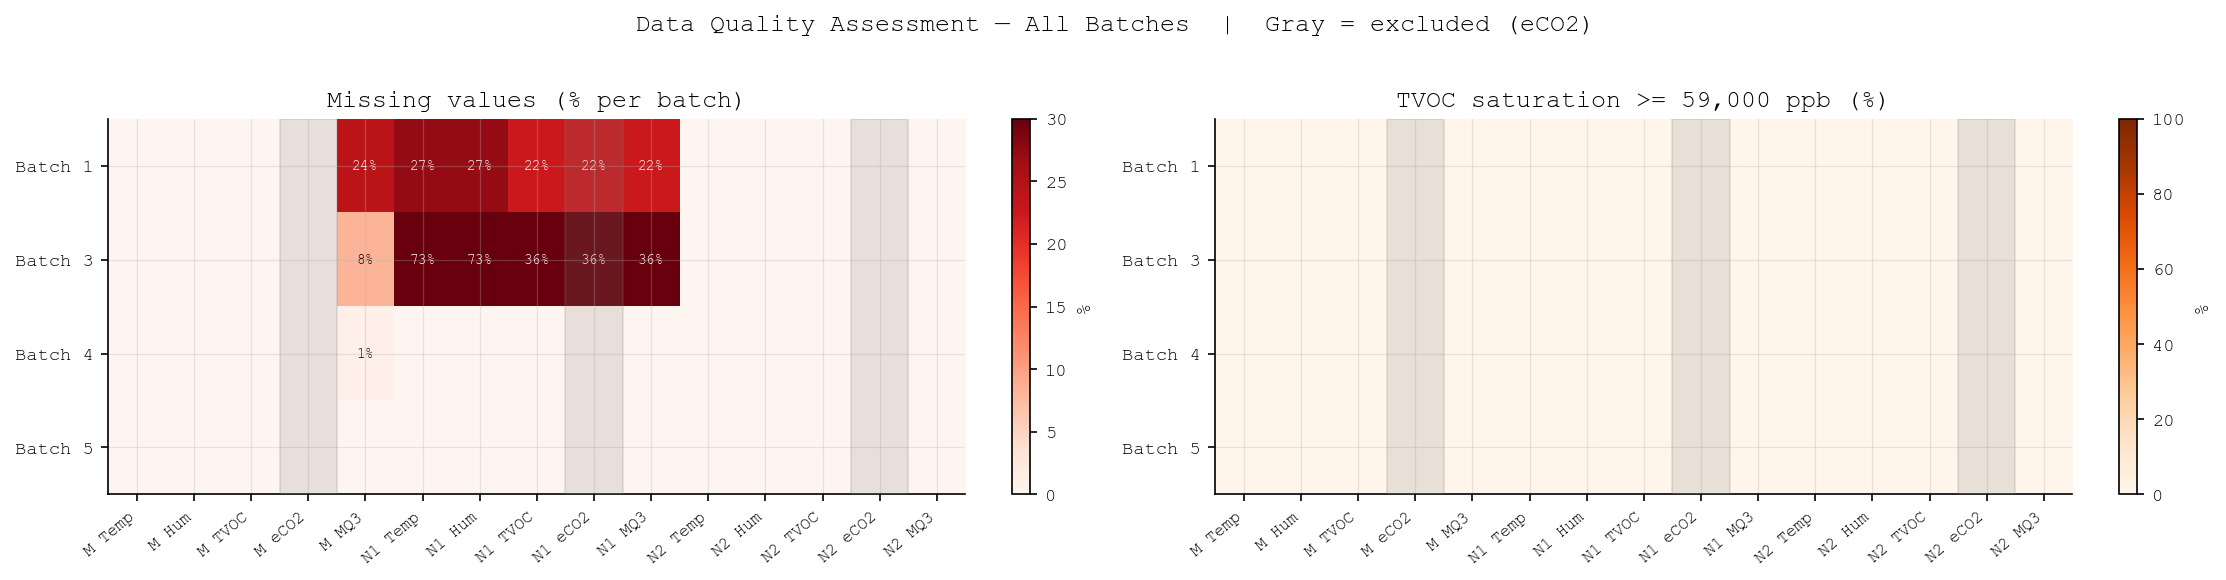

In [5]:
SENSOR_COLS = [
    'master_temp','master_hum','master_tvoc','master_eco2','master_mq3_ppm',
    'node1_temp', 'node1_hum', 'node1_tvoc', 'node1_eco2', 'node1_mq3_ppm',
    'node2_temp', 'node2_hum', 'node2_tvoc', 'node2_eco2', 'node2_mq3_ppm',
]
COL_LABELS = [
    'M Temp','M Hum','M TVOC','M eCO2','M MQ3',
    'N1 Temp','N1 Hum','N1 TVOC','N1 eCO2','N1 MQ3',
    'N2 Temp','N2 Hum','N2 TVOC','N2 eCO2','N2 MQ3',
]
ECO2_IDX = [3, 8, 13]
TVOC_IDX  = [2, 7, 12]

missing_pct = np.zeros((len(BATCH_IDS), len(SENSOR_COLS)))
sat_pct     = np.zeros((len(BATCH_IDS), len(SENSOR_COLS)))

for ri, i in enumerate(BATCH_IDS):
    b = sensor_frames[i]
    for ci, col in enumerate(SENSOR_COLS):
        missing_pct[ri, ci] = 100 * b[col].isna().mean()
        if col in TVOC_COLS:
            sat_pct[ri, ci] = 100 * (b[col] >= TVOC_SAT).mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))

for ax, data, title, cmap, vmax in [
    (axes[0], missing_pct, 'Missing values (% per batch)',              'Reds',    30),
    (axes[1], sat_pct,     f'TVOC saturation >= {TVOC_SAT:,} ppb (%)', 'Oranges', 100),
]:
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(COL_LABELS)))
    ax.set_xticklabels(COL_LABELS, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(len(BATCH_LABELS)))
    ax.set_yticklabels(BATCH_LABELS)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.025, label='%')
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            v = data[r, c]
            if v > 0.5:
                tc = 'white' if v > vmax * 0.55 else 'black'
                ax.text(c, r, f'{v:.0f}%', ha='center', va='center', fontsize=7, color=tc)

for ax in axes:
    for ci in ECO2_IDX:
        ax.axvspan(ci - 0.5, ci + 0.5, color='gray', alpha=0.18, zorder=3)

fig.suptitle('Data Quality Assessment — All Batches  |  Gray = excluded (eCO2)', fontsize=12, y=1.01)
plt.tight_layout()
save_fig('01_data_quality', fig)
plt.show()

## 3. Why eCO2 is excluded

  Saved -> 02_eco2_exclusion.png


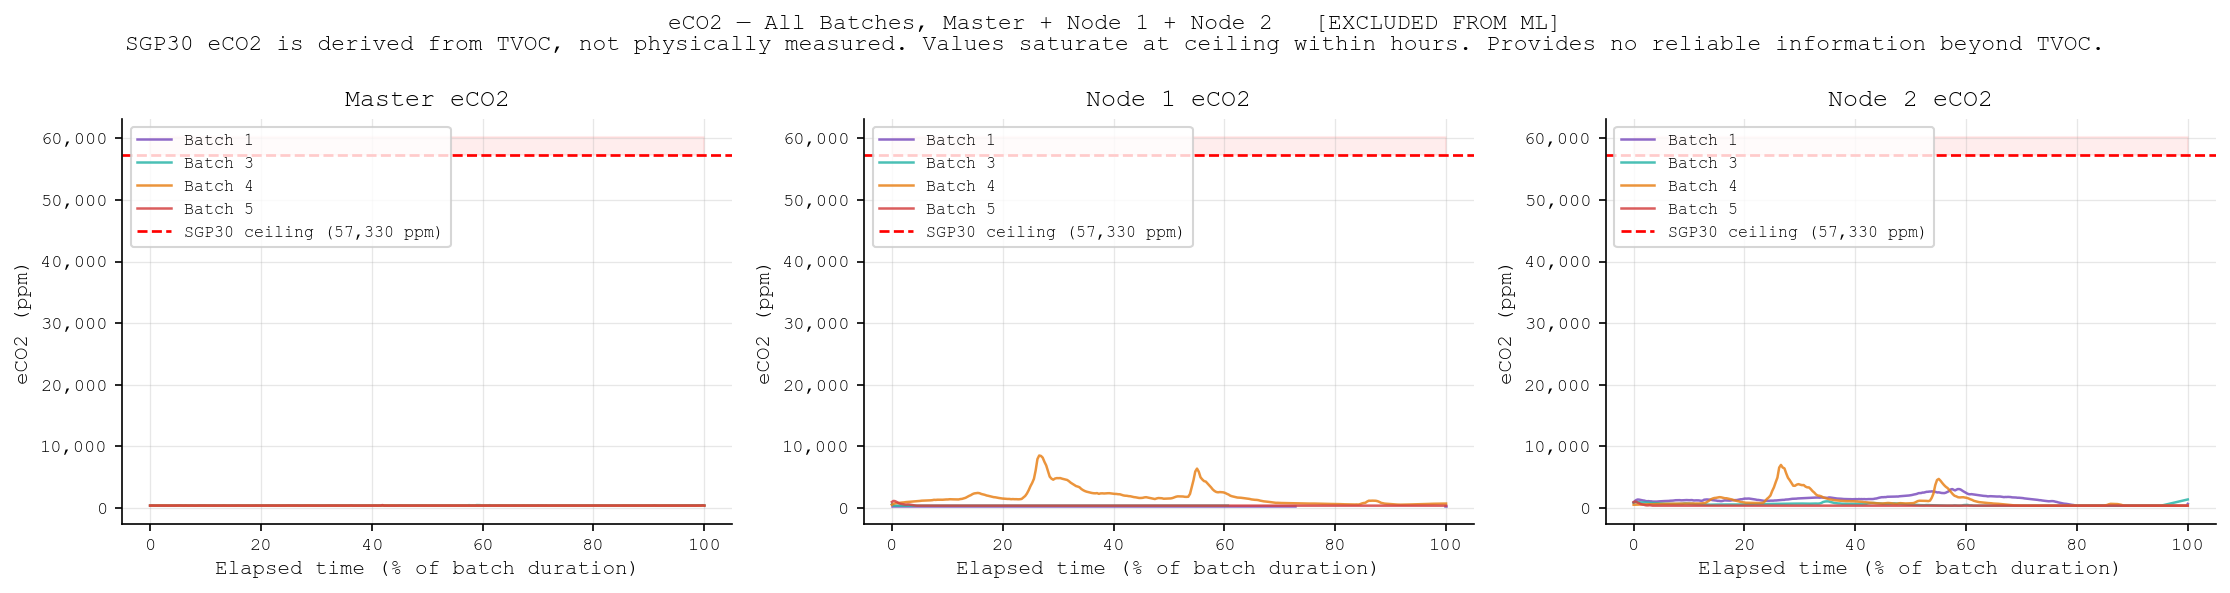

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
eco2_pairs = [('master_eco2', 'Master eCO2'), ('node1_eco2', 'Node 1 eCO2'), ('node2_eco2', 'Node 2 eCO2')]

for ax, (col, col_label) in zip(axes, eco2_pairs):
    for i in BATCH_IDS:
        b    = sensor_frames[i]
        meta = BATCH_META[i]
        pct  = b['elapsed_h'] / b['elapsed_h'].max() * 100
        ax.plot(pct, b[col], color=meta['color'], linewidth=1.2,
                label=meta['label'], alpha=0.85)

    ax.axhline(SGP30_ECO2_MAX, color='red', linestyle='--', linewidth=1.3,
               label=f'SGP30 ceiling ({SGP30_ECO2_MAX:,} ppm)')
    ax.fill_between([0, 100], SGP30_ECO2_MAX, SGP30_ECO2_MAX * 1.05,
                    color='red', alpha=0.07)
    ax.set_title(col_label)
    ax.set_xlabel('Elapsed time (% of batch duration)')
    ax.set_ylabel('eCO2 (ppm)')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(loc='upper left', framealpha=0.8, fontsize=8)

fig.suptitle(
    'eCO2 — All Batches, Master + Node 1 + Node 2   [EXCLUDED FROM ML]\n'
    'SGP30 eCO2 is derived from TVOC, not physically measured. '
    'Values saturate at ceiling within hours. Provides no reliable information beyond TVOC.',
    fontsize=11
)
plt.tight_layout()
save_fig('02_eco2_exclusion', fig)
plt.show()

## 4. Why TVOC saturation readings are excluded

  Saved -> 03_tvoc_saturation.png


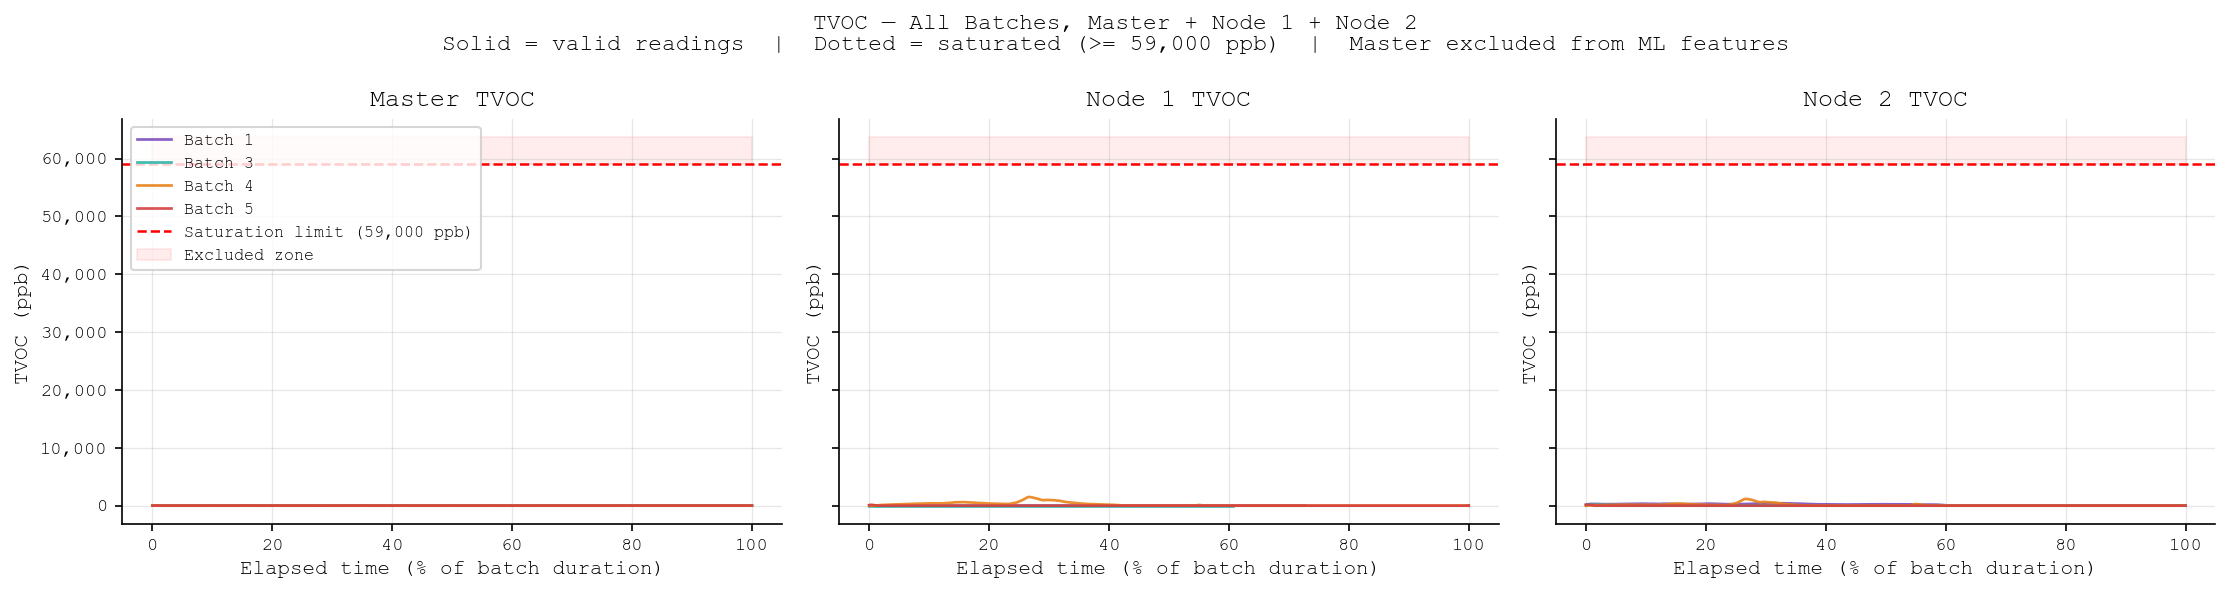

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
tvoc_pairs = [('master_tvoc', 'Master TVOC'), ('node1_tvoc', 'Node 1 TVOC'), ('node2_tvoc', 'Node 2 TVOC')]

for ax, (col, col_label) in zip(axes, tvoc_pairs):
    for i in BATCH_IDS:
        b    = sensor_frames[i]
        meta = BATCH_META[i]
        pct  = b['elapsed_h'] / b['elapsed_h'].max() * 100
        vals = b[col].copy().astype(float)

        valid = vals.where(vals < TVOC_SAT)
        sat   = vals.where(vals >= TVOC_SAT)

        ax.plot(pct, valid, color=meta['color'], linewidth=1.3,
                label=meta['label'], alpha=0.9)
        ax.plot(pct, sat,   color=meta['color'], linewidth=2.2,
                linestyle=':', alpha=0.45)

    ax.axhline(TVOC_SAT, color='red', linestyle='--', linewidth=1.2,
               label=f'Saturation limit ({TVOC_SAT:,} ppb)')
    ax.fill_between([0, 100], TVOC_SAT, TVOC_SAT * 1.08,
                    color='red', alpha=0.07, label='Excluded zone')
    ax.set_title(col_label)
    ax.set_xlabel('Elapsed time (% of batch duration)')
    ax.set_ylabel('TVOC (ppb)')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[0].legend(loc='upper left', framealpha=0.8, fontsize=8)

fig.suptitle(
    'TVOC — All Batches, Master + Node 1 + Node 2\n'
    'Solid = valid readings  |  Dotted = saturated (>= 59,000 ppb)  |  Master excluded from ML features',
    fontsize=11
)
plt.tight_layout()
save_fig('03_tvoc_saturation', fig)
plt.show()

## 5-8. Sensor time series — Temperature, Humidity, TVOC, Ethanol

All three nodes plotted. Master (gray) measures ambient room air and is excluded from ML features.
Node 1 and Node 2 (purple/teal) are inside the decay containers.
Background shading shows the NIR freshness label zone at each point in time.

  Saved -> 04_temp.png


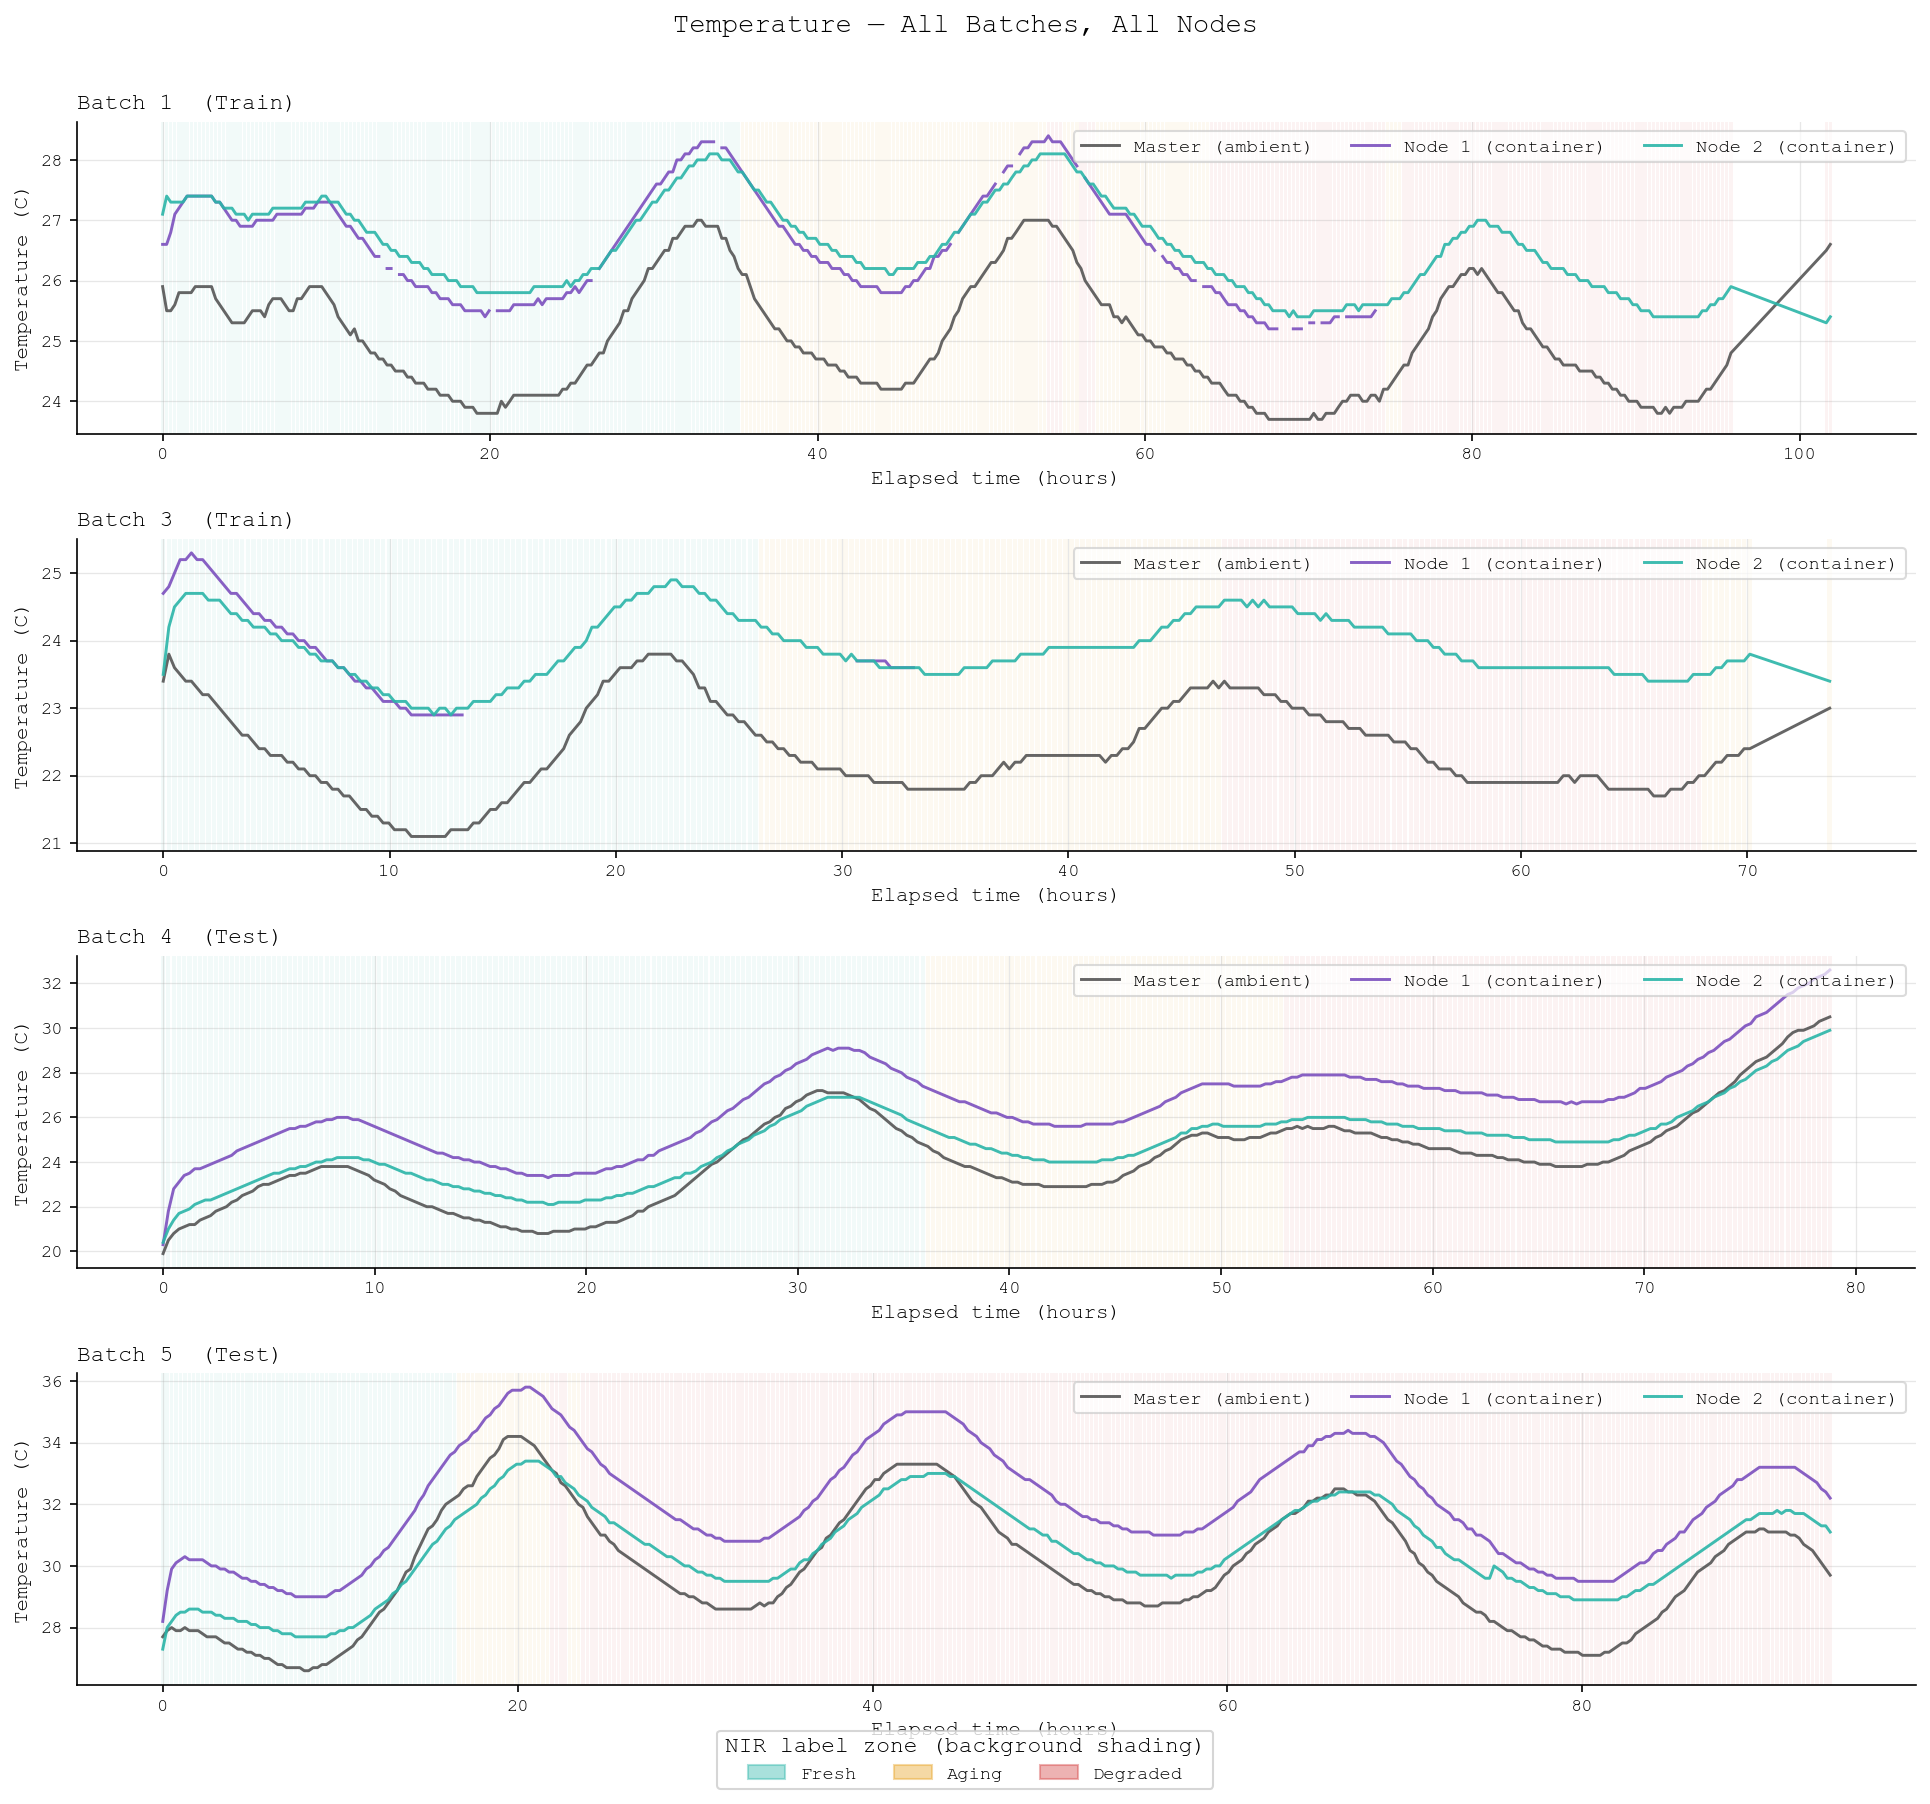

  Saved -> 05_humidity.png


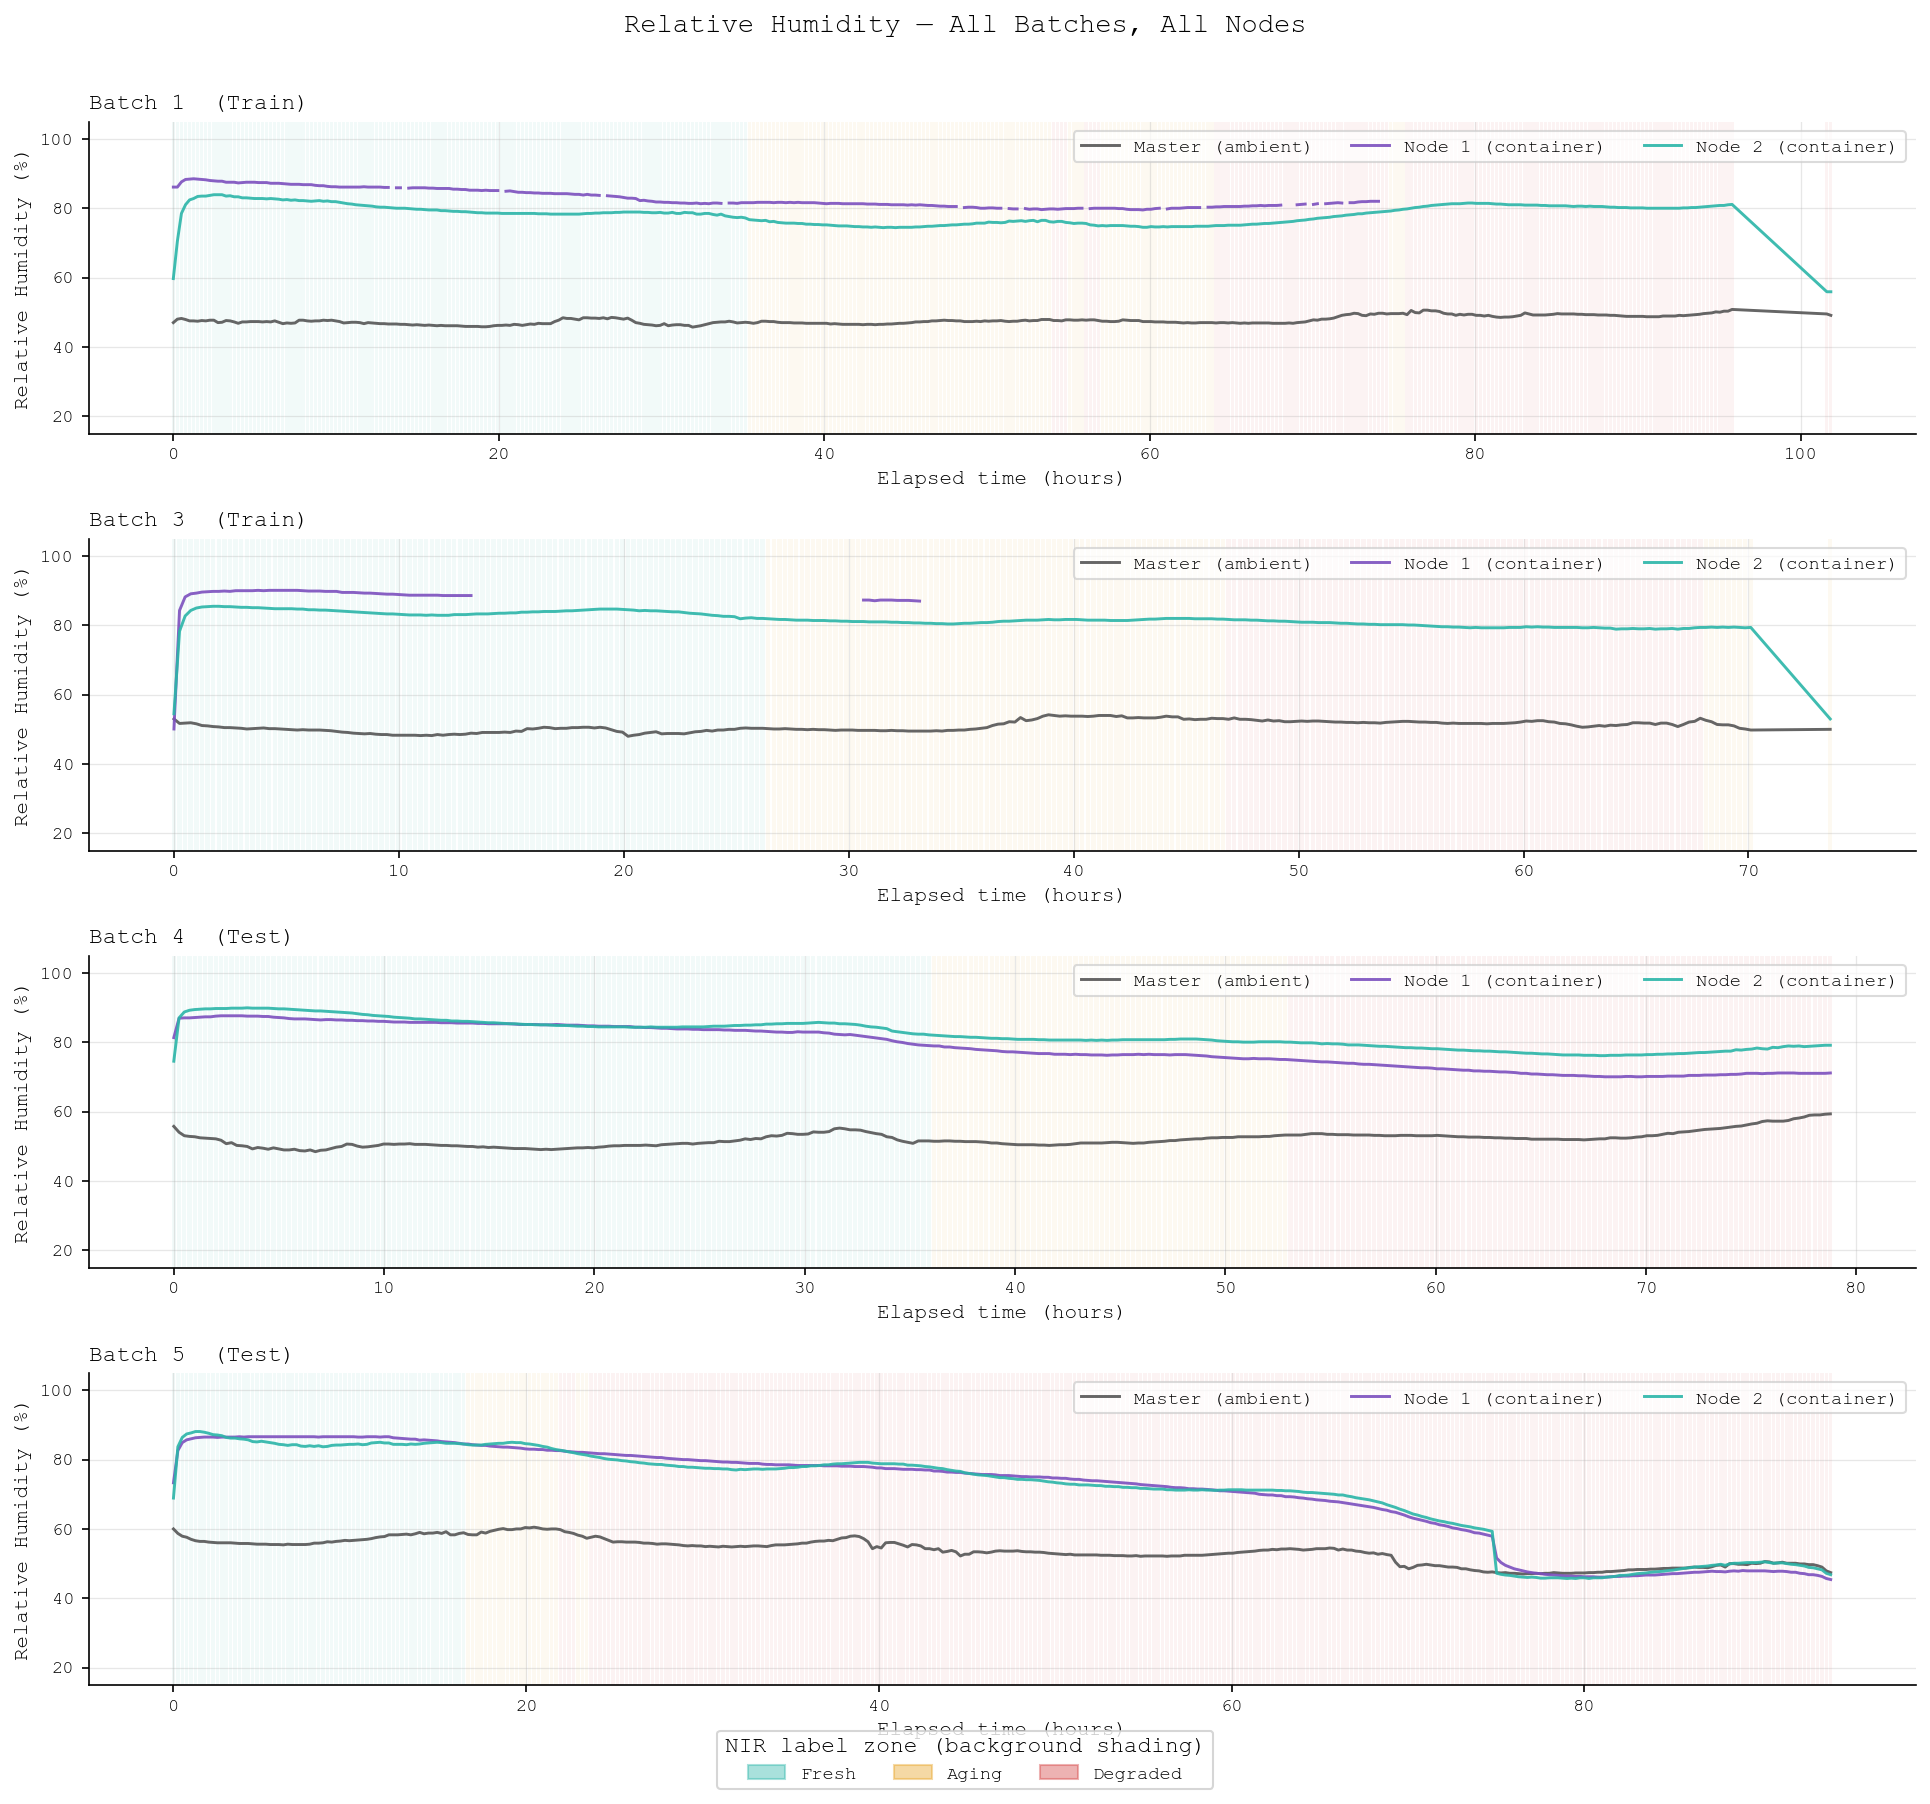

  Saved -> 06_tvoc.png


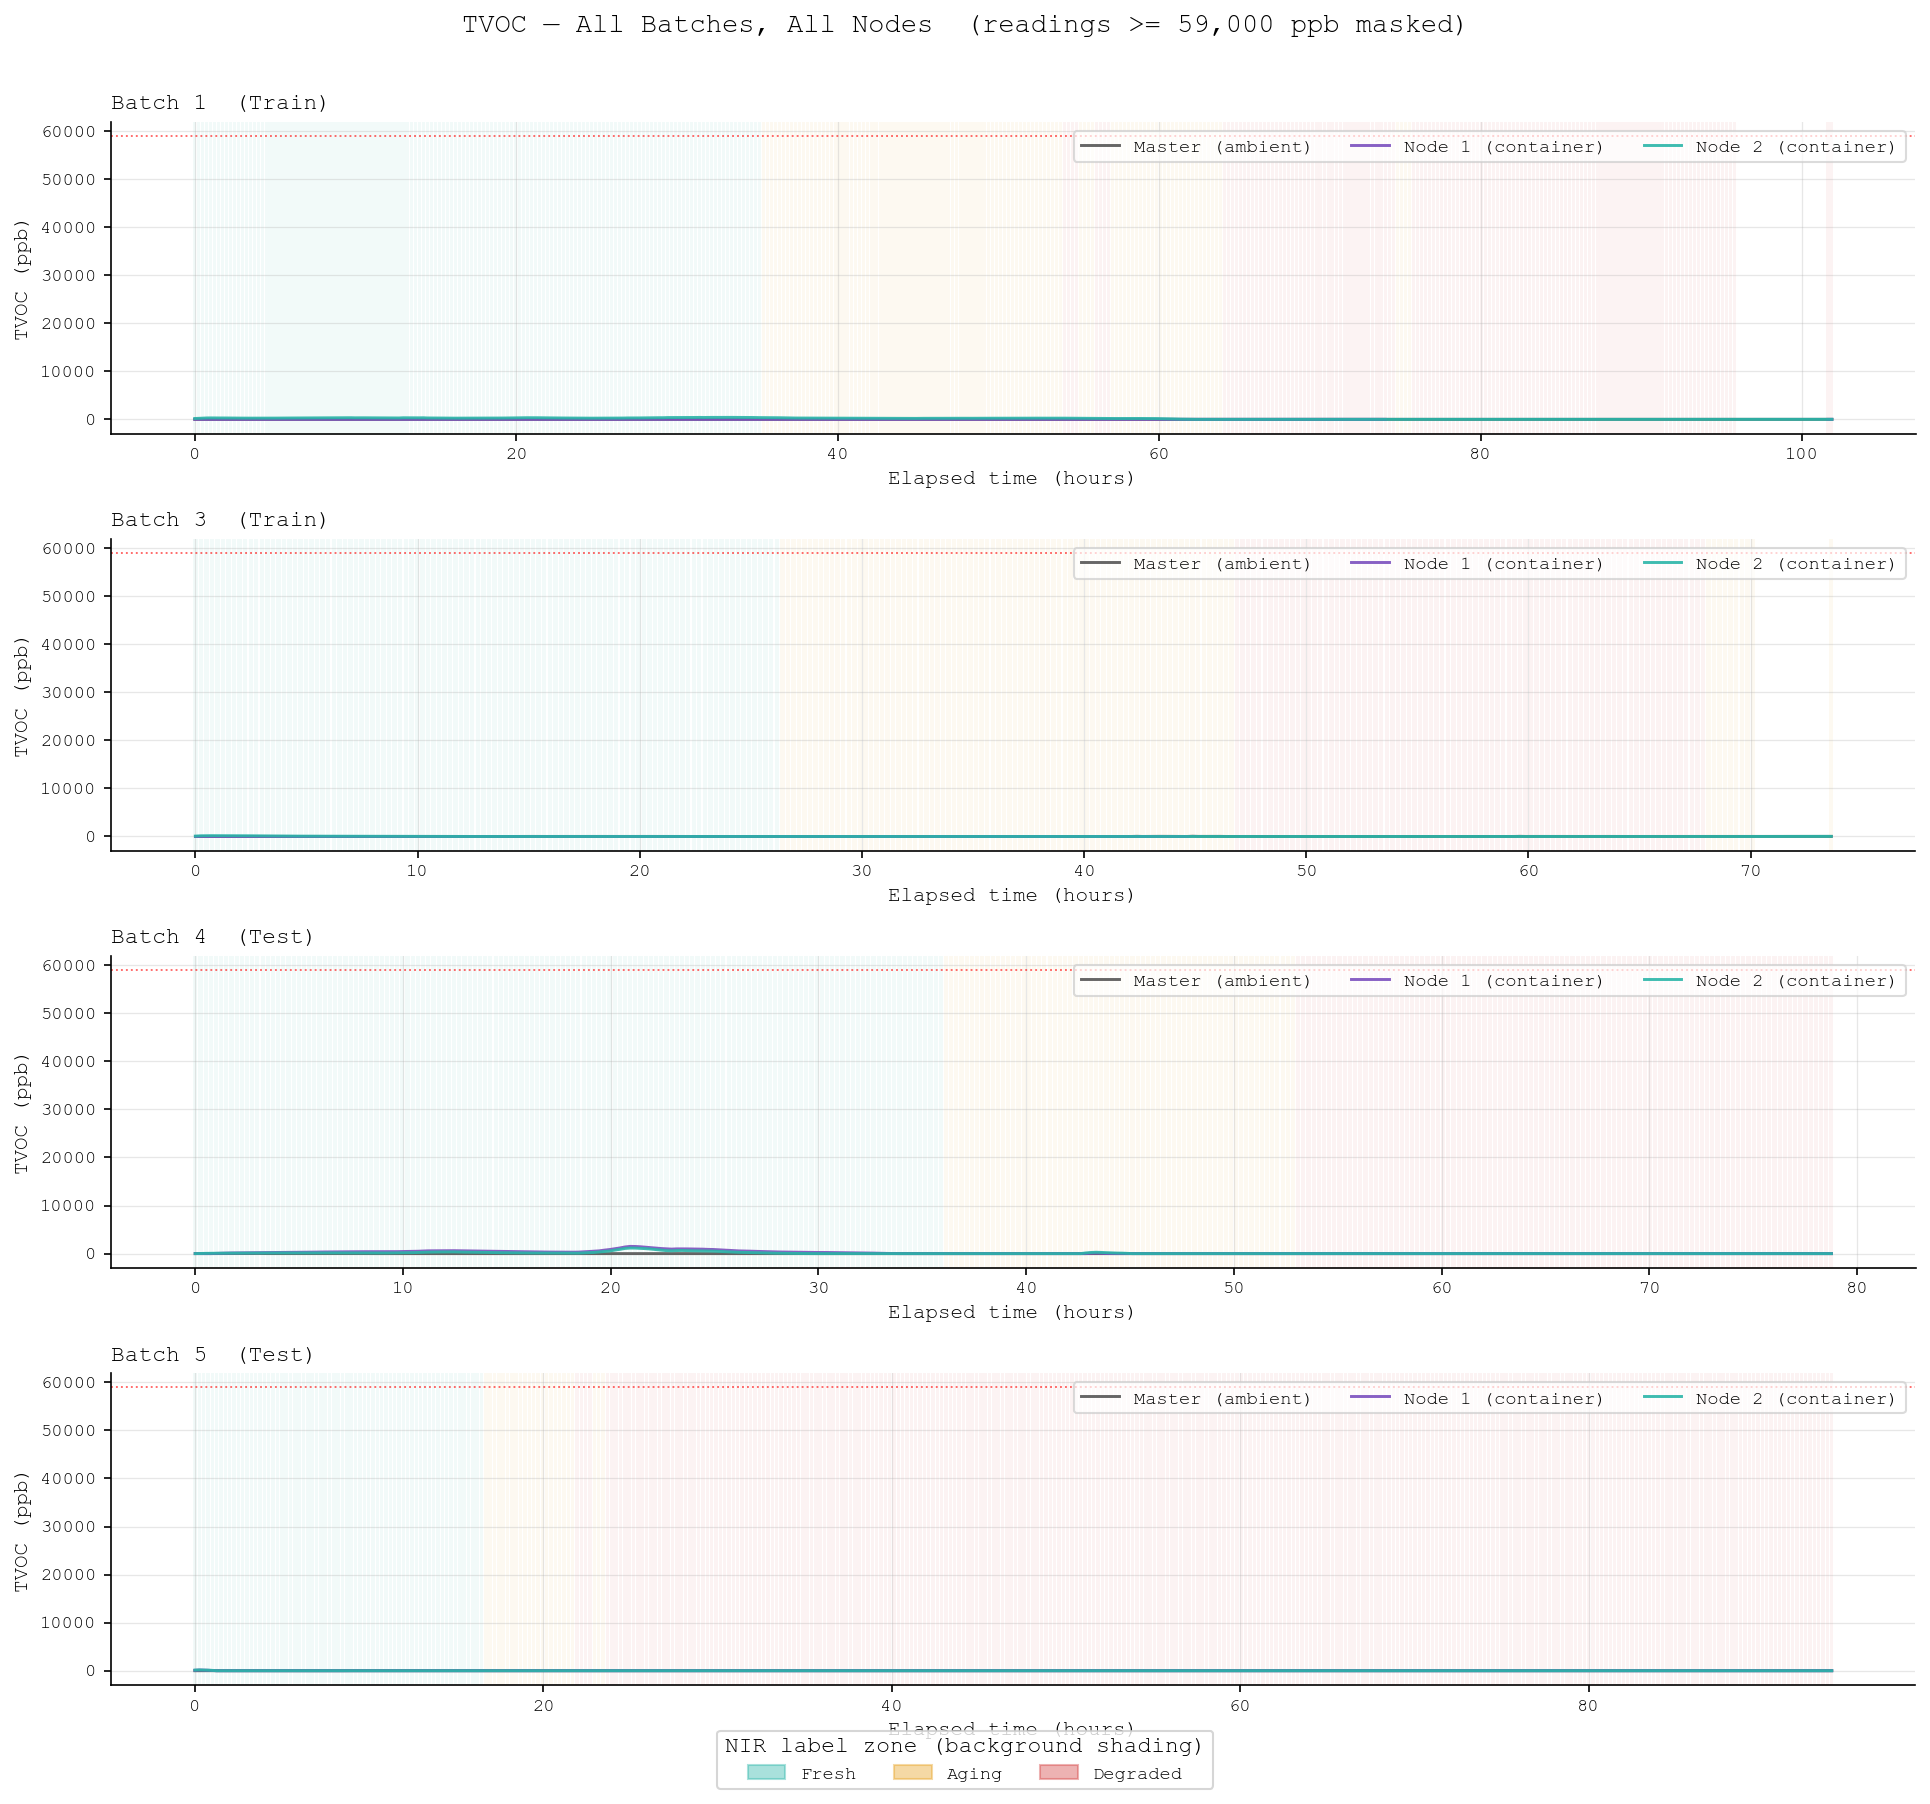

  Saved -> 07_ethanol.png


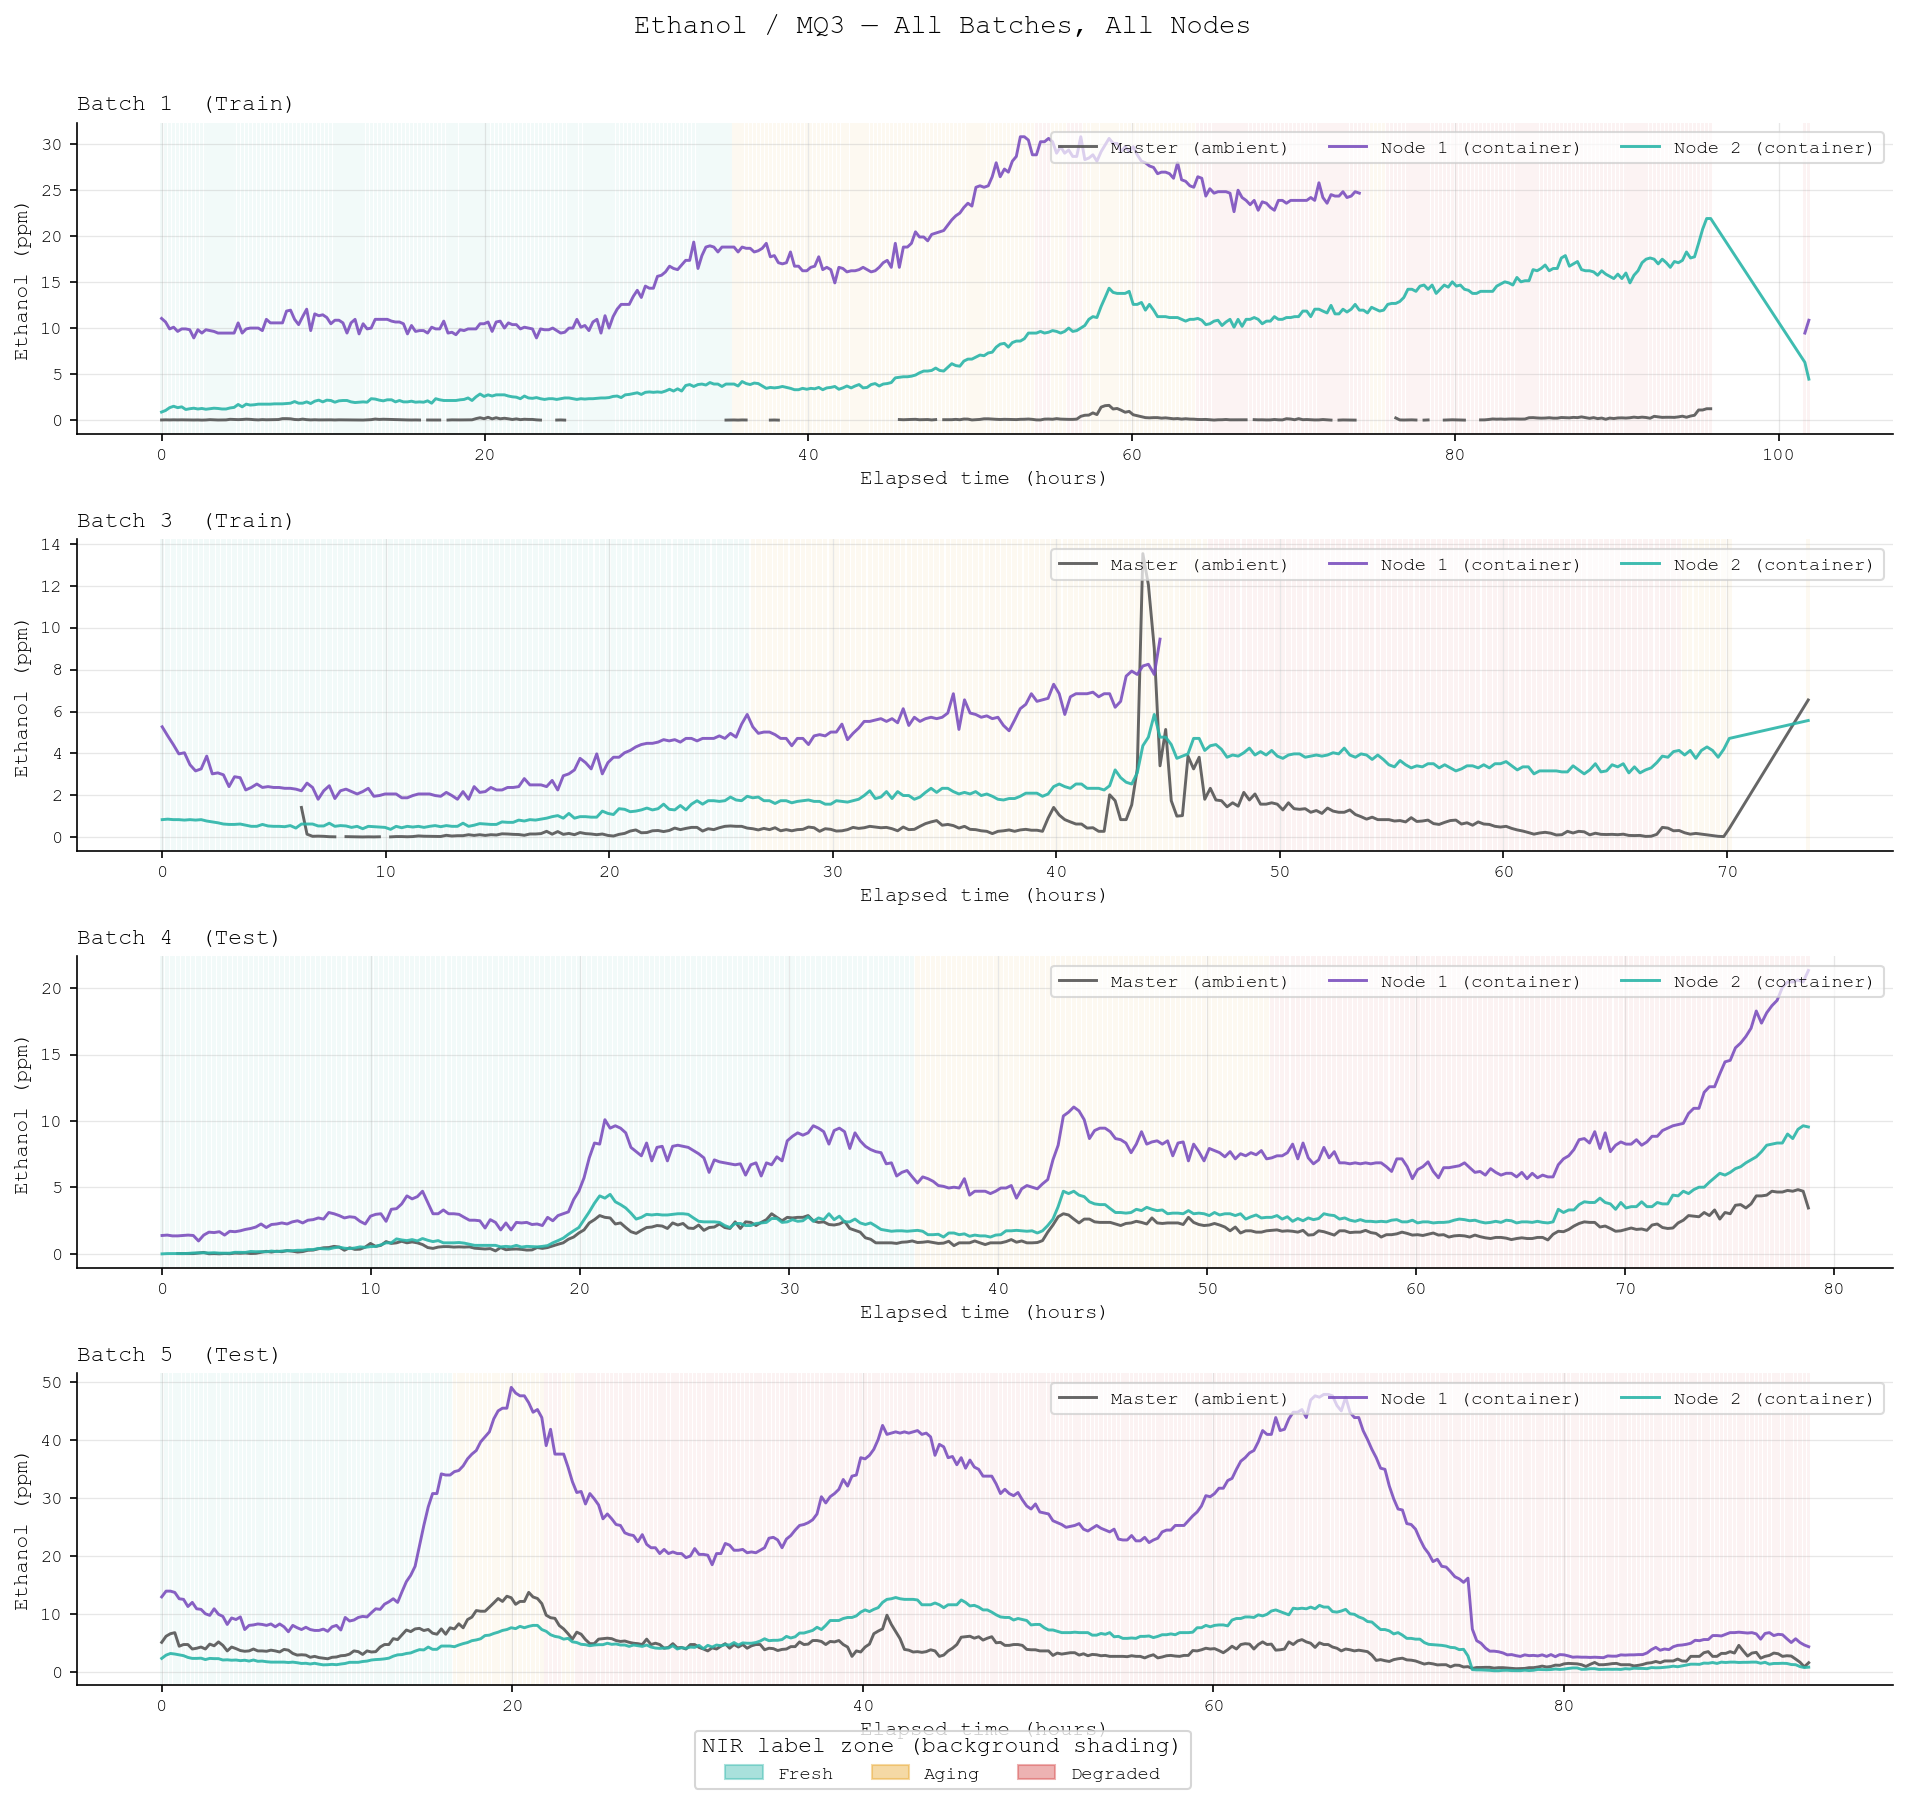

In [8]:
def plot_timeseries(col_template, ylabel, suptitle, filename, ylim=None, sat_threshold=None):
    nodes = ['master', 'node1', 'node2']
    fig, axes = plt.subplots(len(BATCH_IDS), 1, figsize=(13, 2.9 * len(BATCH_IDS)))

    for ax, i in zip(axes, BATCH_IDS):
        b      = sensor_frames[i]
        b_lbl  = df[df['batch'] == i]   # has label column; use only for shading
        meta   = BATCH_META[i]

        # Background shading by NIR class (replaces mould onset line from binary project)
        for _, row in b_lbl.dropna(subset=['label']).iterrows():
            ax.axvspan(row['elapsed_h'] - 0.1, row['elapsed_h'] + 0.1,
                       alpha=0.06, color=CLASS_COLORS[int(row['label'])], linewidth=0)

        for node in nodes:
            col  = col_template.format(node=node)
            vals = b[col].copy().astype(float)
            if sat_threshold is not None:
                vals[vals >= sat_threshold] = np.nan
            ax.plot(b['elapsed_h'], vals, color=NODE_COLORS[node], linewidth=1.4,
                    label=NODE_LABELS[node], alpha=0.9)

        if sat_threshold is not None:
            ax.axhline(sat_threshold, color='red', linestyle=':', linewidth=0.9, alpha=0.6)
        if ylim:
            ax.set_ylim(ylim)

        ax.set_title(f"{meta['label']}  ({'Train' if i in TRAIN_BATCHES else 'Test'})", loc='left', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xlabel('Elapsed time (hours)')
        ax.legend(loc='upper right', framealpha=0.7, ncol=3)

    patches = [mpatches.Patch(color=CLASS_COLORS[v], alpha=0.4, label=CLASS_NAMES[v]) for v in [0,1,2]]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
               title='NIR label zone (background shading)', framealpha=0.8, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(suptitle, fontsize=13, y=1.005)
    plt.tight_layout()
    save_fig(filename, fig)
    plt.show()

plot_timeseries('{node}_temp', 'Temperature (C)',
    'Temperature — All Batches, All Nodes', '04_temp')

plot_timeseries('{node}_hum', 'Relative Humidity (%)',
    'Relative Humidity — All Batches, All Nodes', '05_humidity', ylim=(15, 105))

plot_timeseries('{node}_tvoc', 'TVOC (ppb)',
    f'TVOC — All Batches, All Nodes  (readings >= {TVOC_SAT:,} ppb masked)',
    '06_tvoc', sat_threshold=TVOC_SAT)

plot_timeseries('{node}_mq3_ppm', 'Ethanol (ppm)',
    'Ethanol / MQ3 — All Batches, All Nodes', '07_ethanol')

## 9. Feature distributions by NIR freshness class

Separability between boxes indicates how useful each feature is for the 3-class classifier.
Little overlap is good. Heavy overlap means the model cannot distinguish those classes from that feature alone.
Data is cleaned: eCO2 dropped, TVOC saturated values masked, null MQ3 rows removed.

  Saved -> 08_distributions_by_class.png


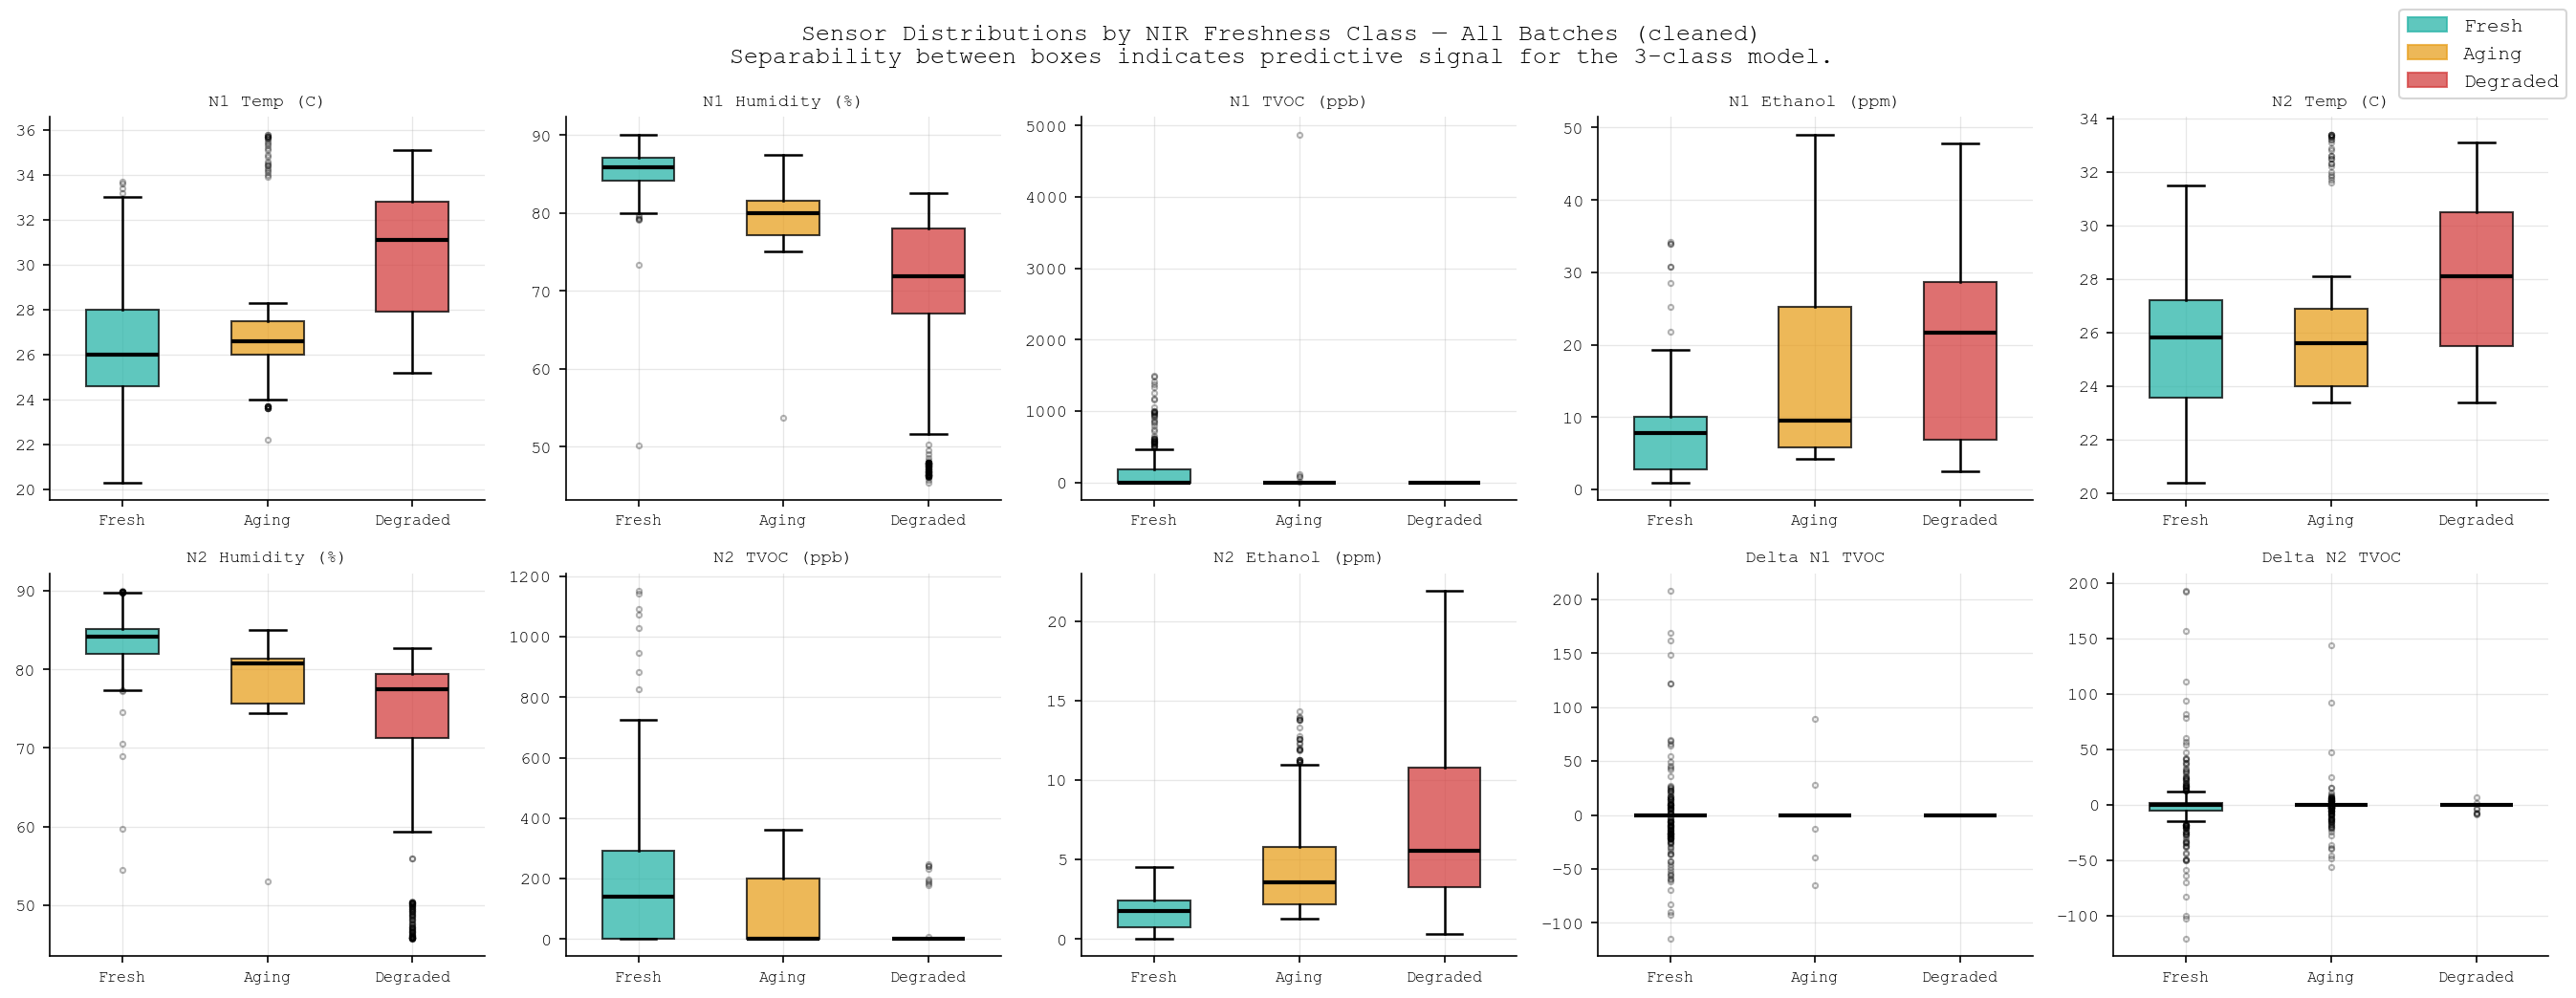

In [9]:
# Apply cleaning (mirrors his df_clean block)
df_clean = df.copy()
df_clean.drop(columns=[c for c in ECO2_COLS if c in df_clean.columns], inplace=True)
for col in TVOC_COLS:
    df_clean.loc[df_clean[col] >= TVOC_SAT, col] = np.nan
df_clean.dropna(subset=['node2_mq3_ppm'], inplace=True)

# Delta TVOC features
for raw, delta in [('node1_tvoc','delta_node1_tvoc'),('node2_tvoc','delta_node2_tvoc')]:
    df_clean[delta] = df_clean.groupby('batch')[raw].diff().fillna(0.0)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for ax, col, lbl in zip(axes, FEATURE_COLS, FEAT_LABELS):
    data_by_class = [df_clean.loc[df_clean['label'] == c, col].dropna() for c in [0,1,2]]

    bp = ax.boxplot(
        data_by_class, patch_artist=True, widths=0.5,
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'linewidth': 1.2}, capprops={'linewidth': 1.2},
        flierprops={'marker': 'o', 'markersize': 2.5, 'alpha': 0.3},
    )
    for patch, c in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(CLASS_COLORS[c])
        patch.set_alpha(0.75)

    ax.set_xticklabels([CLASS_NAMES[c] for c in [0,1,2]], fontsize=8)
    ax.set_title(lbl, fontsize=9)

patches = [mpatches.Patch(color=CLASS_COLORS[v], alpha=0.75, label=CLASS_NAMES[v]) for v in [0,1,2]]
fig.legend(handles=patches, loc='upper right', fontsize=10, framealpha=0.8)

fig.suptitle(
    'Sensor Distributions by NIR Freshness Class — All Batches (cleaned)\n'
    'Separability between boxes indicates predictive signal for the 3-class model.',
    fontsize=12
)
plt.tight_layout()
save_fig('08_distributions_by_class', fig)
plt.show()

## 10. Feature correlation with NIR label

Pearson correlation matrix across all features plus the NIR label.
Bar chart shows each feature's linear correlation with the freshness label (0=Fresh, 1=Aging, 2=Degraded).
Computed on the training set (Batches 1 and 3) to avoid using test data.

  Saved -> 09_pearson_correlation.png


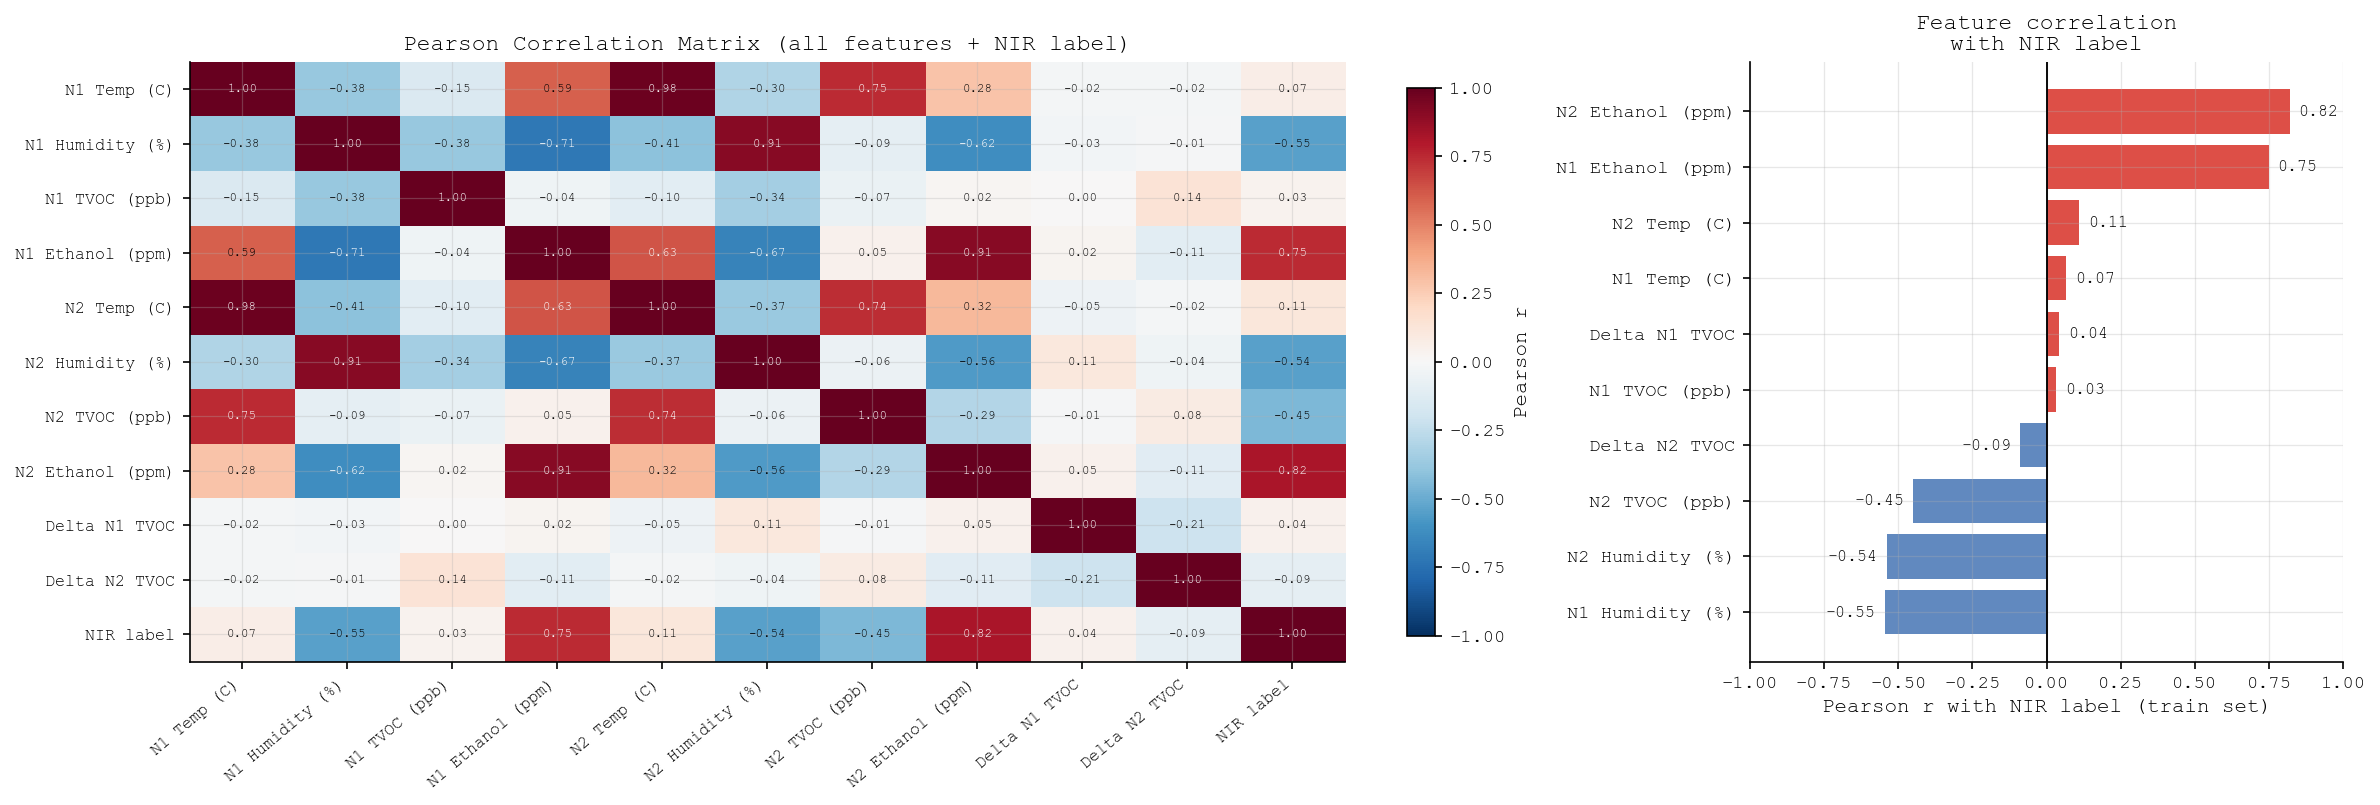

In [10]:
train_df = df_clean[df_clean['batch'].isin(TRAIN_BATCHES)].copy()
held_df  = df_clean[df_clean['batch'].isin(HELD_BATCHES)].copy()
test_df  = df_clean[df_clean['batch'].isin(TEST_BATCHES)].copy()

all_cols   = FEATURE_COLS + ['label']
all_labels = FEAT_LABELS  + ['NIR label']
corr_data  = train_df[all_cols].dropna()
corr_matrix = corr_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'width_ratios': [2.1, 1]})

# Full heatmap
ax = axes[0]
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(all_labels)))
ax.set_yticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(all_labels, fontsize=8)
ax.set_title('Pearson Correlation Matrix (all features + NIR label)', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.022, label='Pearson r')
for r in range(len(all_labels)):
    for c in range(len(all_labels)):
        v  = corr_matrix.values[r, c]
        tc = 'white' if abs(v) > 0.62 else 'black'
        ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=6, color=tc)

# Bar chart
ax2 = axes[1]
lc  = corr_matrix['label'][FEATURE_COLS].sort_values()
colors = ['#d73027' if v >= 0 else '#4575b4' for v in lc]
bars = ax2.barh(range(len(lc)), lc.values, color=colors, alpha=0.85)
ax2.set_yticks(range(len(lc)))
ax2.set_yticklabels([FEAT_LABELS[FEATURE_COLS.index(c)] for c in lc.index], fontsize=9)
ax2.axvline(0, color='black', linewidth=0.9)
ax2.set_xlabel('Pearson r with NIR label (train set)')
ax2.set_title('Feature correlation\nwith NIR label', fontsize=11)
ax2.set_xlim(-1, 1)
for bar, val in zip(bars, lc.values):
    offset = 0.03 if val >= 0 else -0.03
    ha     = 'left' if val >= 0 else 'right'
    ax2.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha=ha, fontsize=8)

plt.tight_layout()
save_fig('09_pearson_correlation', fig)
plt.show()

## 11. Train / Test split summary

Final cleaned dataset split:
Split          Batches  Samples     Fresh     Aging  Degraded
Train Batch 1, Batch 3      670 248 (37%) 203 (30%) 219 (33%)
 Held          Batch 5      378  67 (18%)   24 (6%) 287 (76%)
 Test          Batch 4      317 145 (46%)  68 (21%) 104 (33%)
  Saved -> 10_dataset_split.png


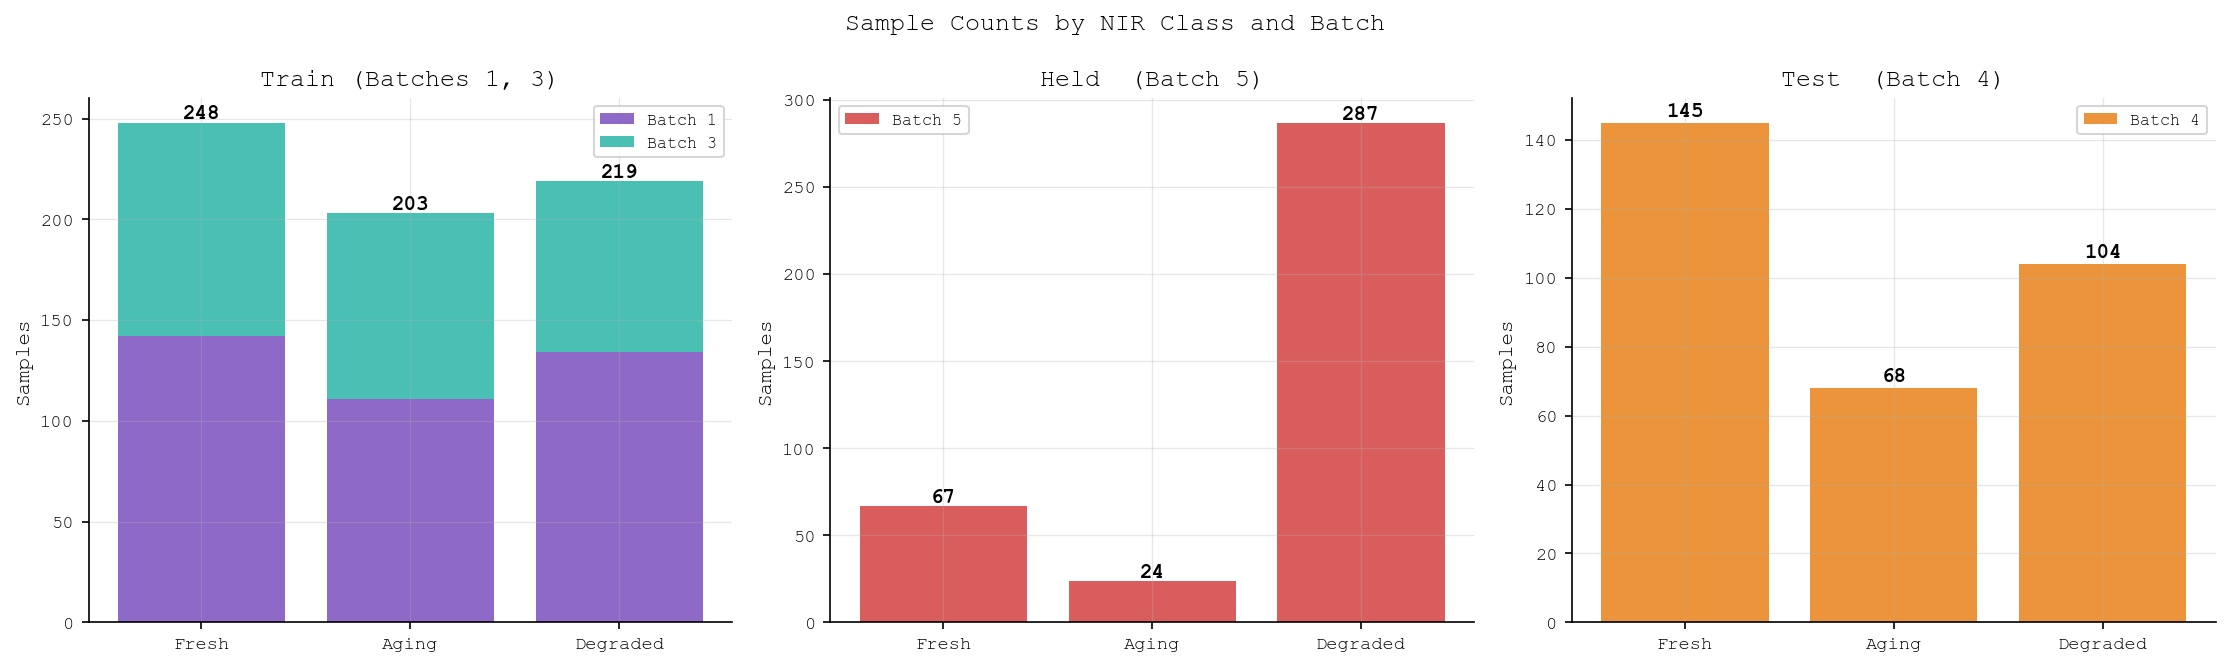

In [11]:
split_rows = []
for name, split_df, batches in [
    ('Train', train_df, TRAIN_BATCHES),
    ('Held',  held_df,  HELD_BATCHES),
    ('Test',  test_df,  TEST_BATCHES),
]:
    total = len(split_df)
    row = {
        'Split':   name,
        'Batches': ', '.join(BATCH_META[b]['label'] for b in batches),
        'Samples': total,
    }
    for c in [0,1,2]:
        n = int((split_df['label'] == c).sum())
        row[CLASS_NAMES[c]] = f"{n} ({100*n/total:.0f}%)"
    split_rows.append(row)

print('Final cleaned dataset split:')
print(pd.DataFrame(split_rows).to_string(index=False))

# Stacked bar
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (split_name, split_df, batches) in zip(axes, [
    ('Train (Batches 1, 3)', train_df, TRAIN_BATCHES),
    ('Held  (Batch 5)',      held_df,  HELD_BATCHES),
    ('Test  (Batch 4)',      test_df,  TEST_BATCHES),
]):
    bottoms = [0, 0, 0]
    for b in batches:
        b_df = split_df[split_df['batch'] == b]
        heights = [(b_df['label'] == c).sum() for c in [0,1,2]]
        ax.bar([0,1,2], heights, bottom=bottoms,
               color=BATCH_META[b]['color'], alpha=0.85, label=BATCH_META[b]['label'])
        bottoms = [bottoms[j] + heights[j] for j in range(3)]

    ax.set_xticks([0,1,2])
    ax.set_xticklabels([CLASS_NAMES[c] for c in [0,1,2]])
    ax.set_ylabel('Samples')
    ax.set_title(split_name)
    ax.legend(fontsize=8)
    for j, total_h in enumerate(bottoms):
        ax.text(j, total_h + 2, str(int(total_h)), ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Sample Counts by NIR Class and Batch', fontsize=12)
plt.tight_layout()
save_fig('10_dataset_split', fig)
plt.show()

## 12. Feature distributions by NIR class — density view

Overlapping density histograms per feature across all three freshness classes.
Complements the boxplots in Section 9: boxplots show spread and outliers,
histograms show the full shape of each distribution.
Heavy overlap between classes means the classifier cannot separate them from that feature alone.

  Saved -> 11b_feature_distributions_density.png


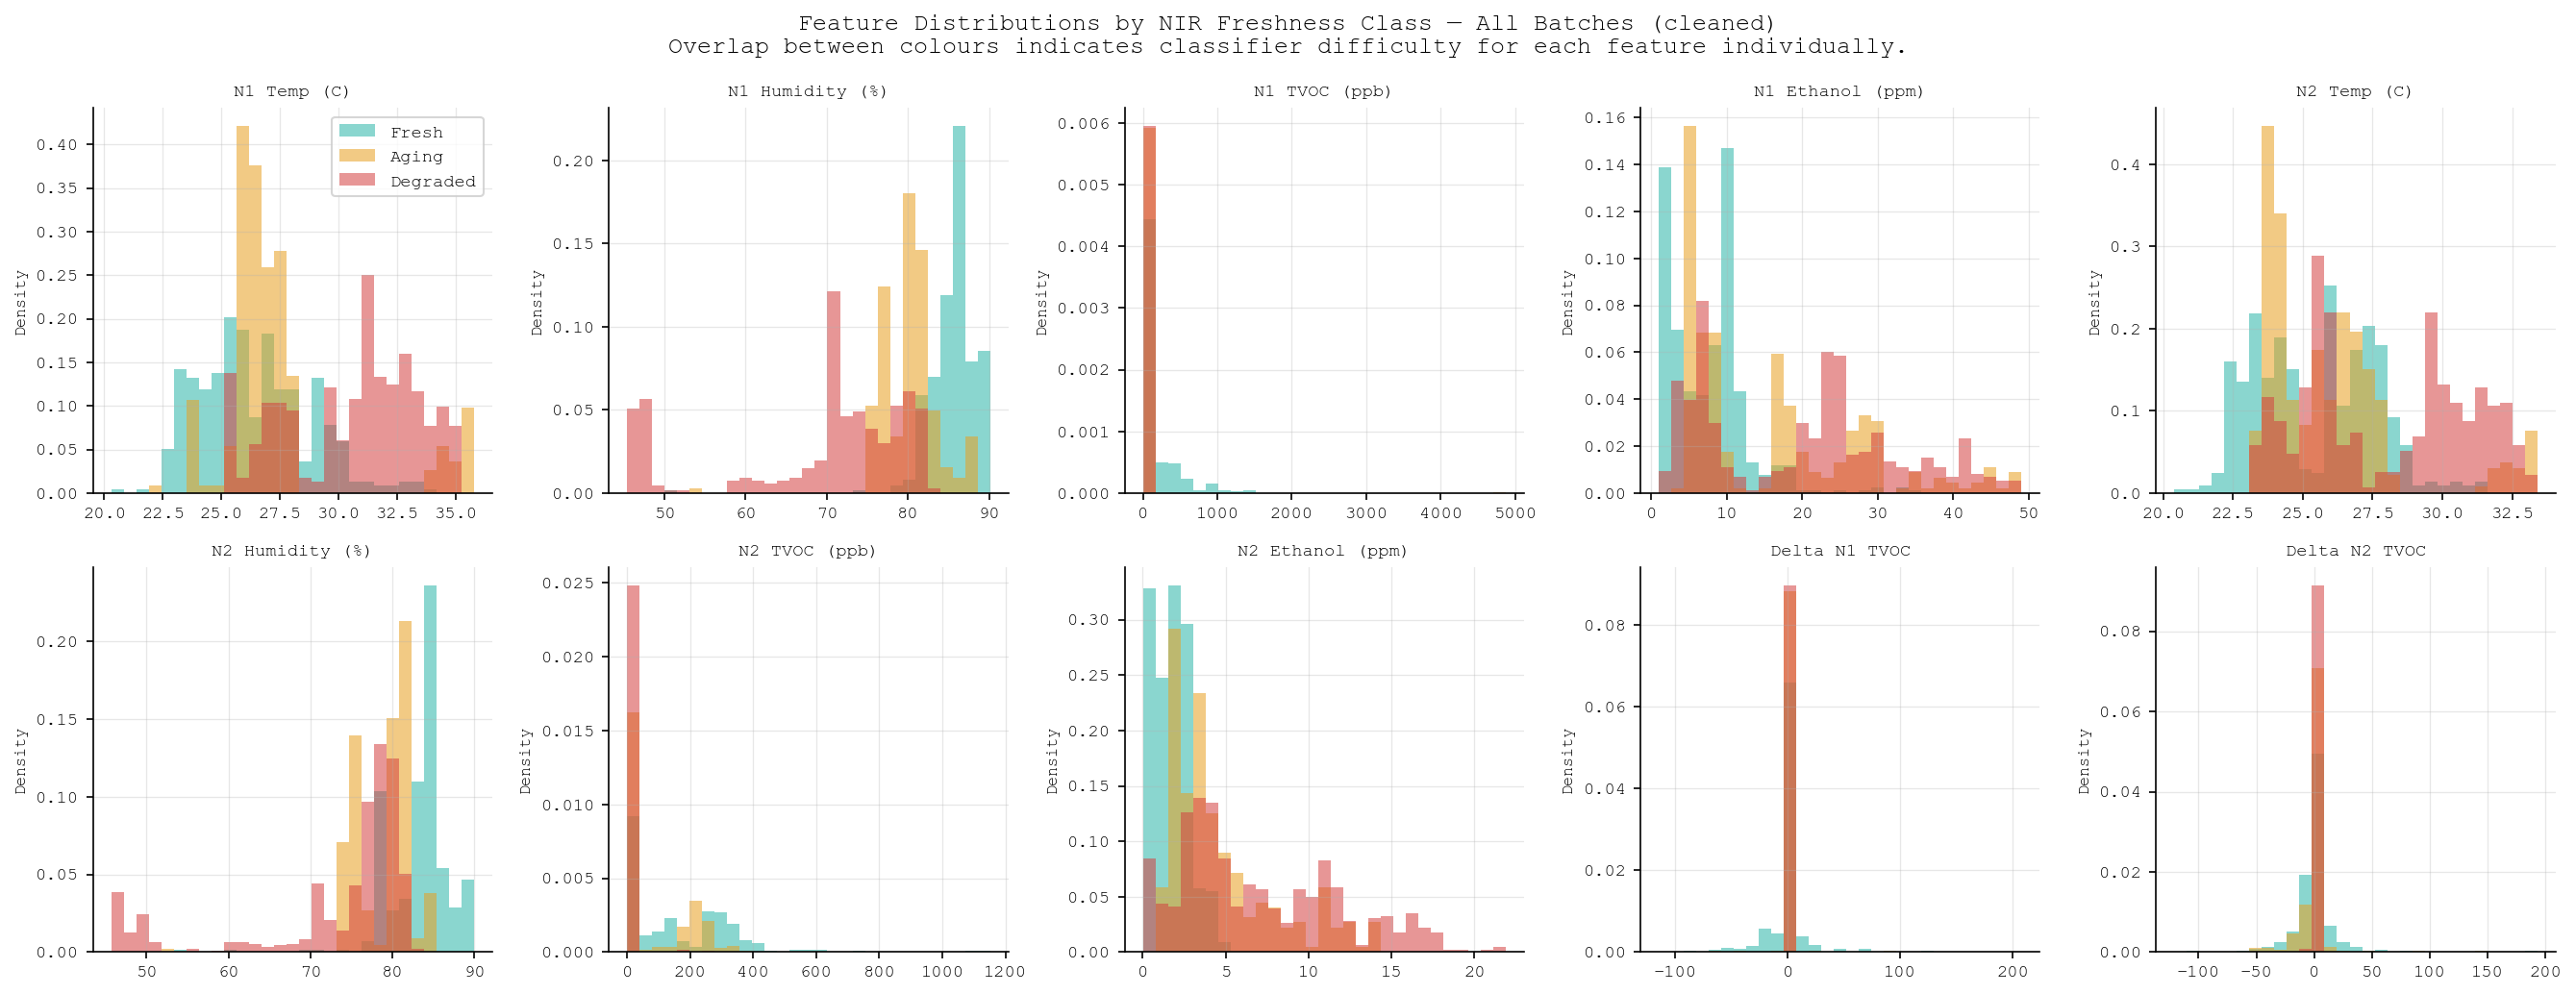


Cleaned dataset (all batches):
  Total   : 1365 samples
  Fresh     : 460
  Aging     : 295
  Degraded  : 610


In [12]:
df_all = df_clean[df_clean['batch'].isin(TRAIN_BATCHES + HELD_BATCHES + TEST_BATCHES)].copy()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for ax, col, lbl in zip(axes, FEATURE_COLS, FEAT_LABELS):
    class_data = [df_all.loc[df_all['label'] == c, col].dropna() for c in [0, 1, 2]]
    valid = [d for d in class_data if len(d) > 1]
    if not valid:
        ax.set_title(lbl, fontsize=9)
        continue

    lo  = min(d.min() for d in valid)
    hi  = max(d.max() for d in valid)
    bins = np.linspace(lo, hi, 30)

    for c, d in zip([0, 1, 2], class_data):
        if len(d) > 1:
            ax.hist(d, bins=bins, alpha=0.55, color=CLASS_COLORS[c],
                    label=CLASS_NAMES[c], density=True, edgecolor='none')

    ax.set_title(lbl, fontsize=9)
    ax.set_ylabel('Density', fontsize=8)

axes[0].legend(fontsize=9, framealpha=0.8)

fig.suptitle(
    'Feature Distributions by NIR Freshness Class — All Batches (cleaned)\n'
    'Overlap between colours indicates classifier difficulty for each feature individually.',
    fontsize=12
)
plt.tight_layout()
save_fig('11b_feature_distributions_density', fig)
plt.show()

print(f'\nCleaned dataset (all batches):')
print(f'  Total   : {len(df_all)} samples')
for c in [0, 1, 2]:
    print(f'  {CLASS_NAMES[c]:<10}: {(df_all["label"]==c).sum()}')

---

## 12. Lighting artifact detection  *(new — AS7341 specific)*

The AS7341 clear channel spikes when ambient lighting changes (room lights on/off, sunlight shifts).
Readings above 1.6x the per-batch clear median are flagged and excluded from NIR zone computation.
They still receive a forward-filled label from the most recent clean reading.

  Saved -> 11_lighting_artifacts.png


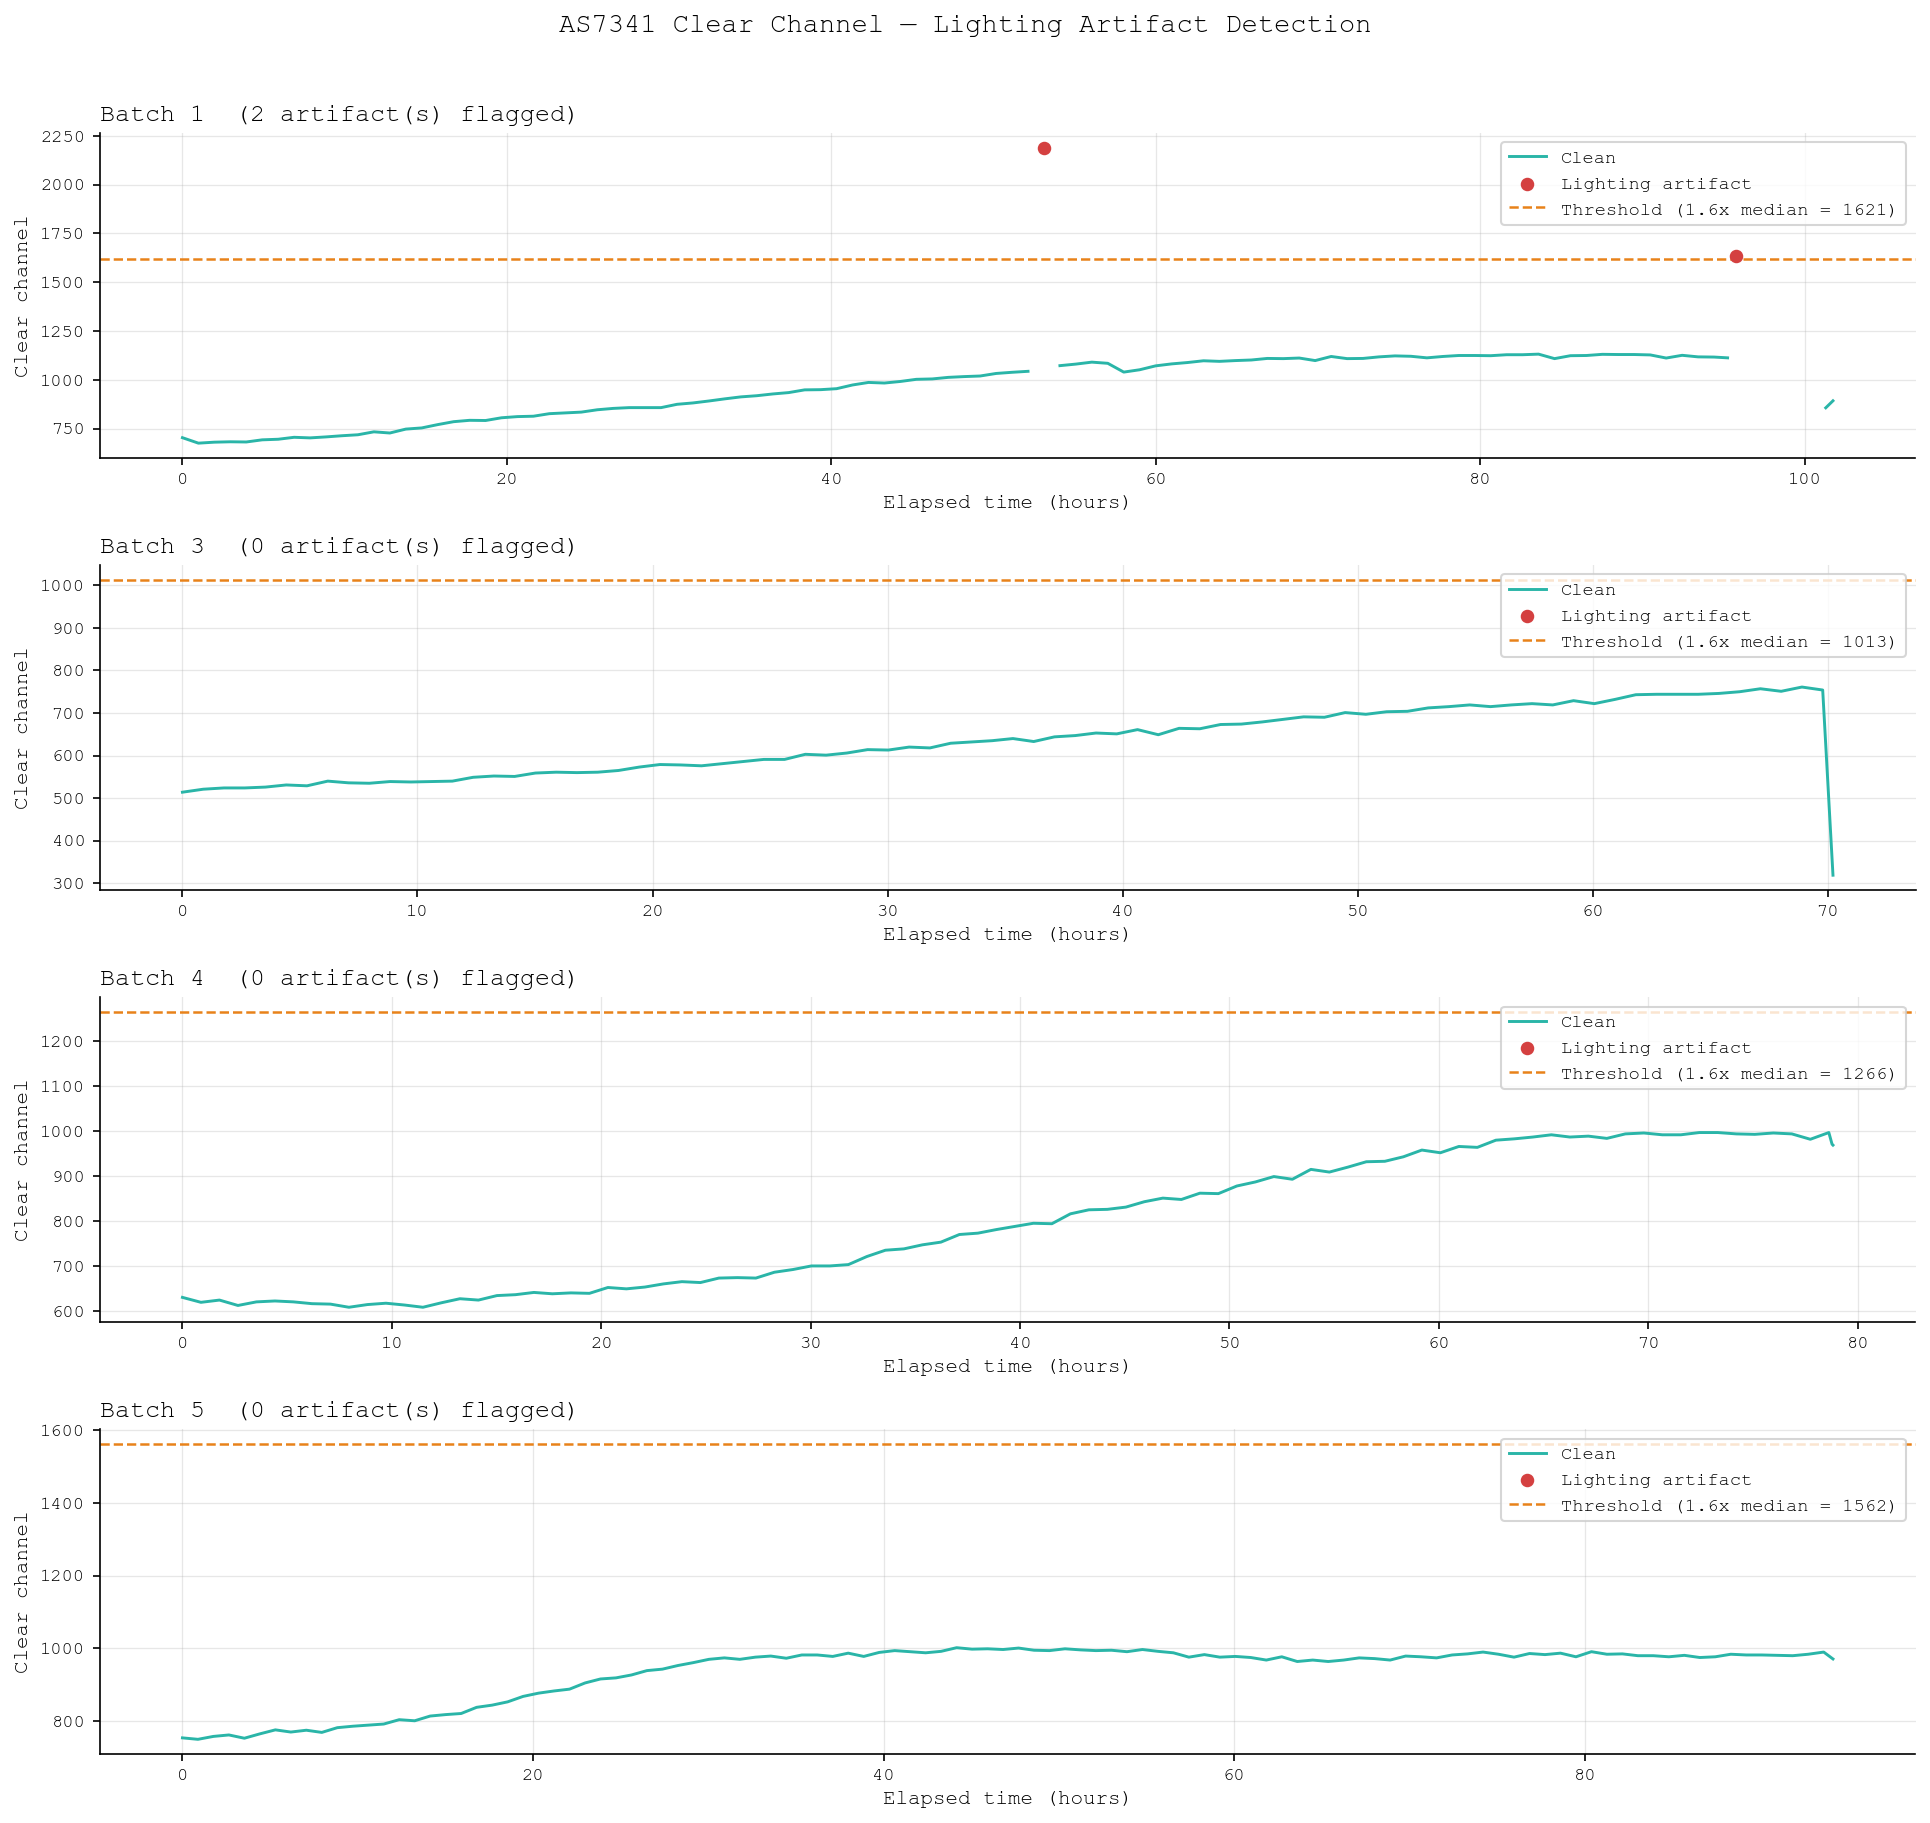

In [13]:
fig, axes = plt.subplots(len(BATCH_IDS), 1, figsize=(13, 3 * len(BATCH_IDS)))

for ax, i in zip(axes, BATCH_IDS):
    m   = spectral_frames[i]
    meta = BATCH_META[i]
    threshold = m['clear'].median() * LIGHTING_FACTOR

    clean = m['clear'].where(~m['lit_flag'])
    lit   = m['clear'].where(m['lit_flag'])

    ax.plot(m['elapsed_h'], clean, color='#2AB5A8', linewidth=1.4, label='Clean')
    ax.scatter(m.loc[m['lit_flag'], 'elapsed_h'], lit.dropna(),
               color='#D44040', s=30, zorder=5, label='Lighting artifact')
    ax.axhline(threshold, color='#E8821A', linestyle='--', linewidth=1.2,
               label=f'Threshold (1.6x median = {threshold:.0f})')
    ax.set_title(f"{meta['label']}  ({zone_summary[i]['n_lit']} artifact(s) flagged)", loc='left')
    ax.set_ylabel('Clear channel')
    ax.set_xlabel('Elapsed time (hours)')
    ax.legend(loc='upper right', framealpha=0.8)

fig.suptitle('AS7341 Clear Channel — Lighting Artifact Detection', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('11_lighting_artifacts', fig)
plt.show()

## 13. NIR channel and zone boundaries  *(new — AS7341 specific)*

The NIR signal is smoothed with a 7-point rolling mean, then split into tertiles to define Fresh/Aging/Degraded zones.
Direction is determined by comparing the first 3 readings to the last 3 — a rising NIR means increasing degradation,
a falling NIR means the opposite.

  Saved -> 12_nir_zones.png


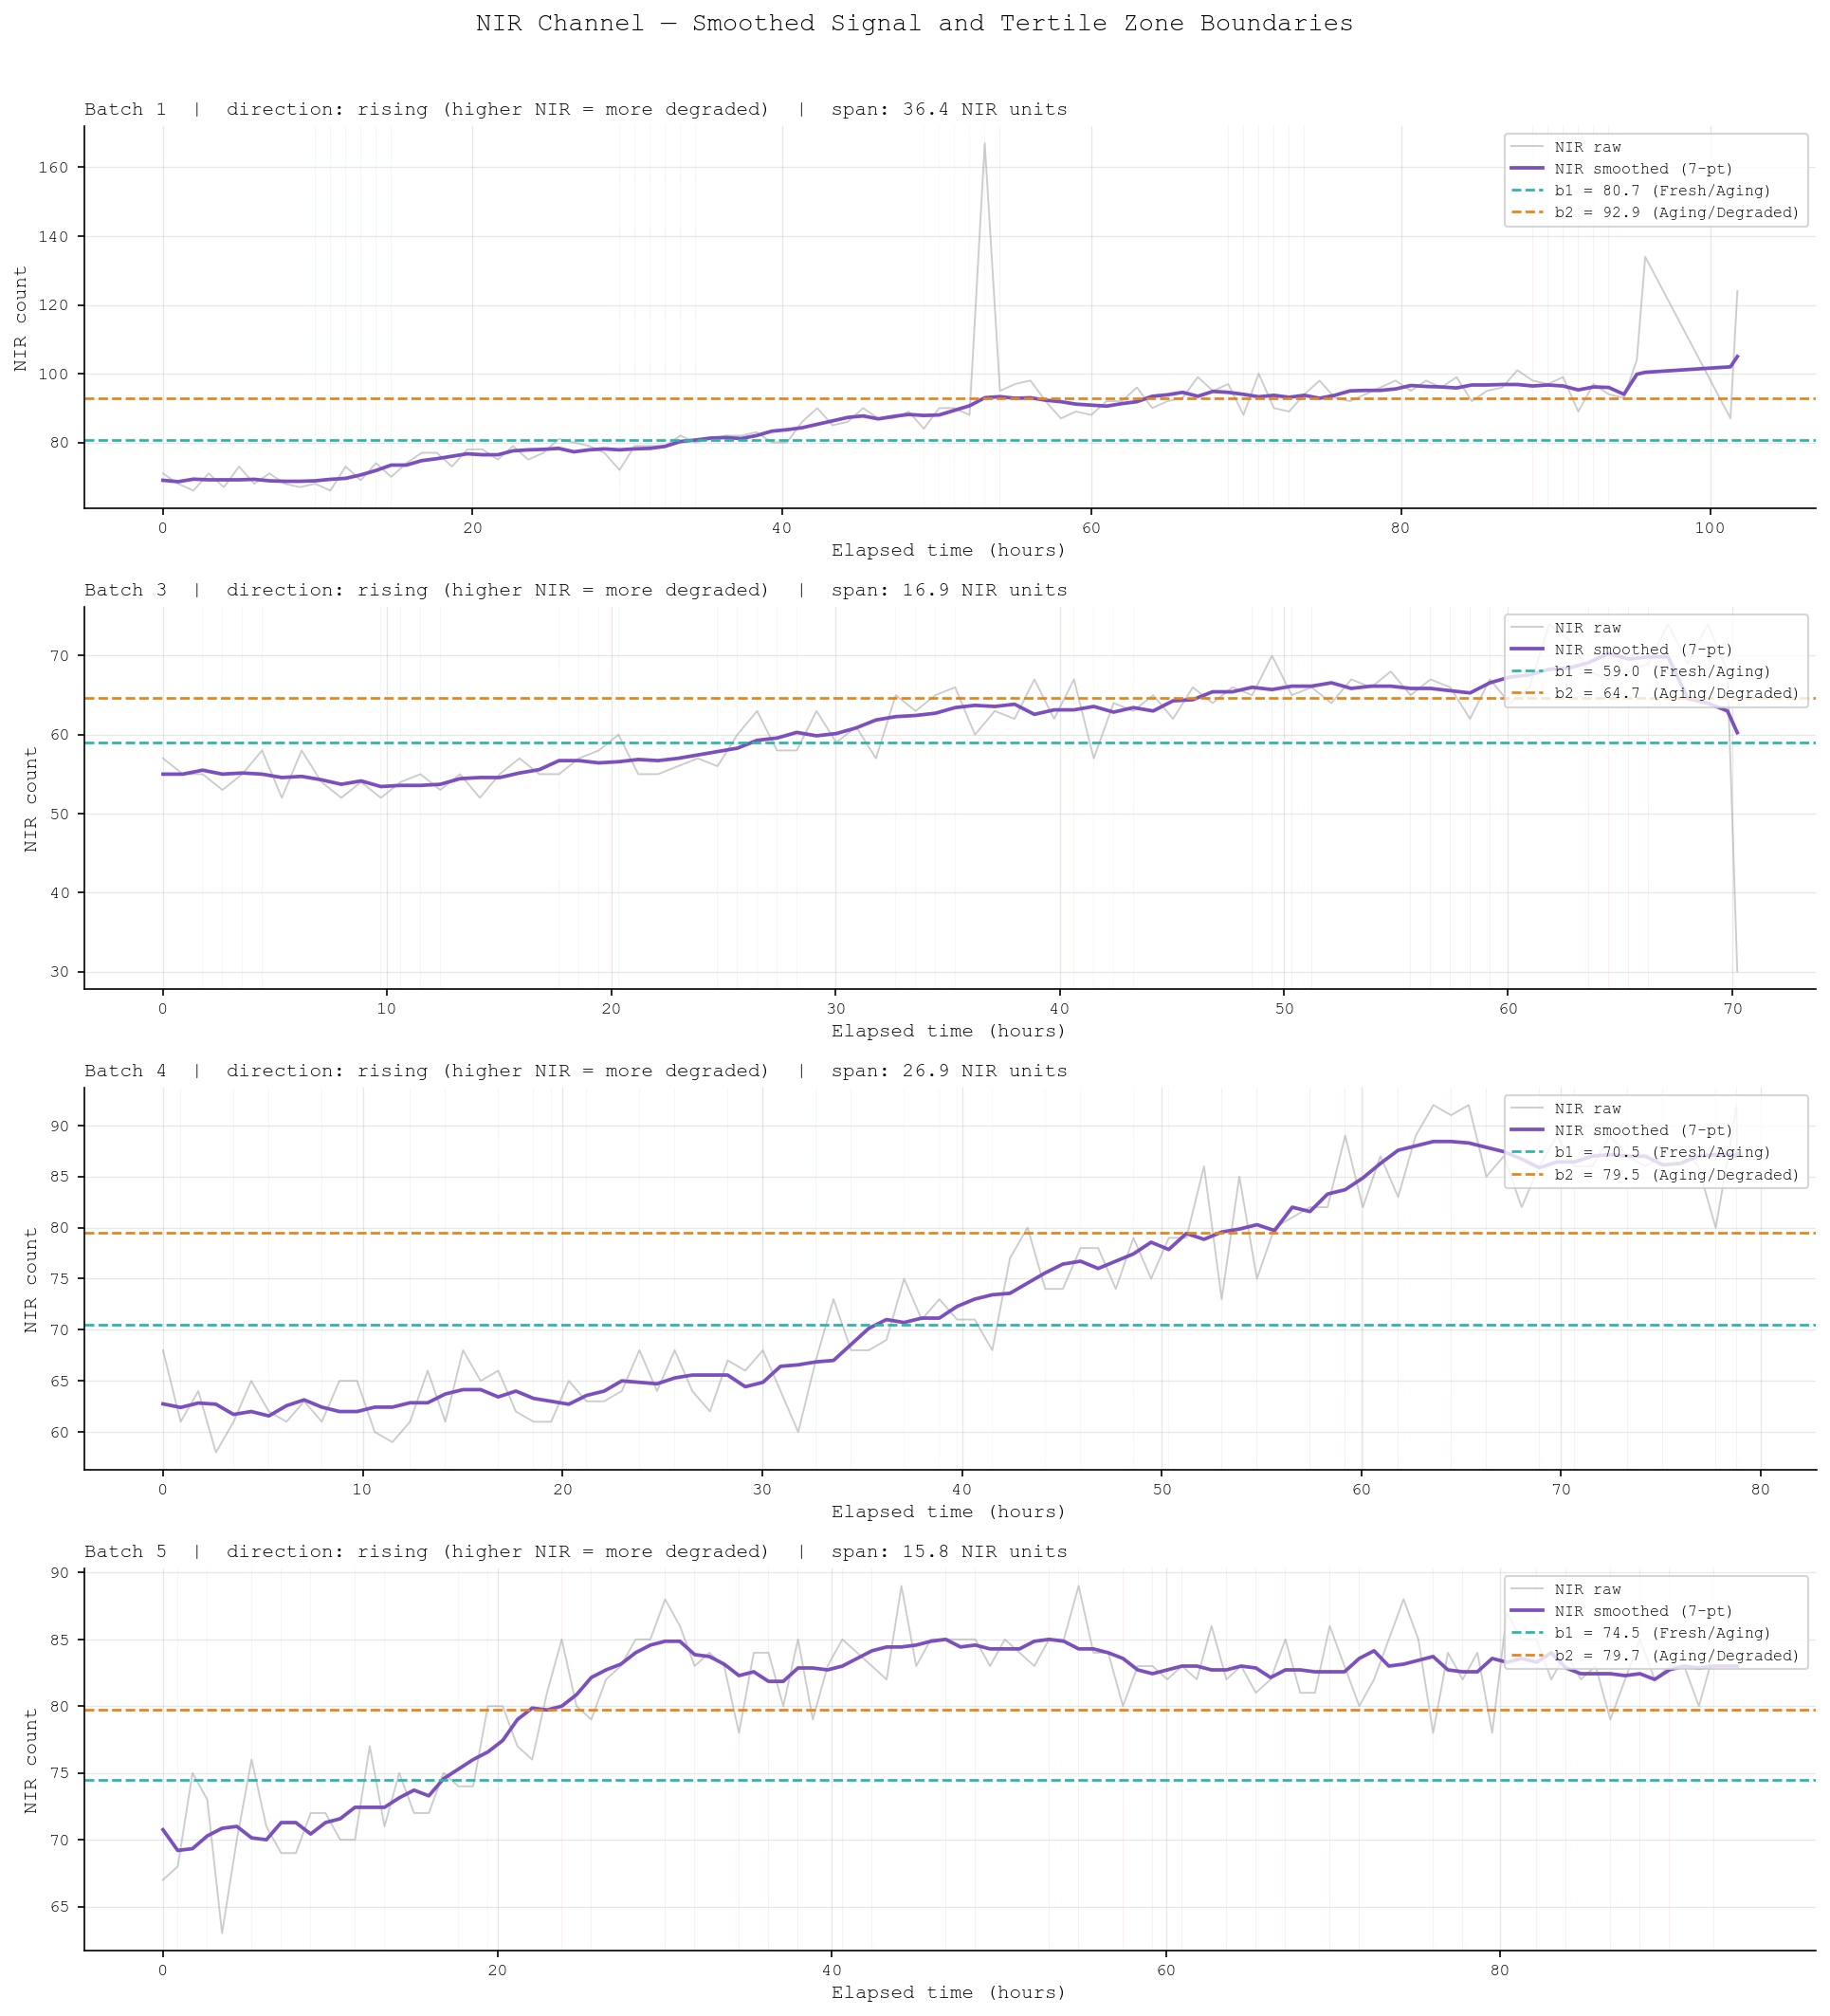

  Batch Split Direction NIR lo NIR hi b1 (Fresh/Aging) b2 (Aging/Degraded) Span
Batch 1 Train    rising   68.6  105.0             80.7                92.9 36.4
Batch 3 Train    rising   53.4   70.3             59.0                64.7 16.9
Batch 4  Test    rising   61.6   88.4             70.5                79.5 26.9
Batch 5  Test    rising   69.2   85.0             74.5                79.7 15.8


In [14]:
fig, axes = plt.subplots(len(BATCH_IDS), 1, figsize=(13, 3.5 * len(BATCH_IDS)))

for ax, i in zip(axes, BATCH_IDS):
    m    = spectral_frames[i]
    meta = BATCH_META[i]
    z    = zone_summary[i]['zones']

    ax.plot(m['elapsed_h'], m['nir'], color='#AAAAAA', linewidth=0.9, alpha=0.6, label='NIR raw')
    ax.plot(m['elapsed_h'], m['nir_smoothed'], color='#7B4FBE', linewidth=1.8,
            label='NIR smoothed (7-pt)')

    if z:
        ax.axhline(z['b1'], color='#2AB5A8', linestyle='--', linewidth=1.3,
                   label=f"b1 = {z['b1']:.1f} (Fresh/Aging)")
        ax.axhline(z['b2'], color='#E8821A', linestyle='--', linewidth=1.3,
                   label=f"b2 = {z['b2']:.1f} (Aging/Degraded)")

        dir_label = 'rising (higher NIR = more degraded)' if z['dir'] > 0 else 'falling (lower NIR = more degraded)'
        for row in m.itertuples():
            if pd.isna(row.nir_label):
                continue
            c = CLASS_COLORS[LABEL_MAP[row.nir_label]]
            ax.axvspan(row.elapsed_h - 0.01, row.elapsed_h + 0.01, alpha=0.08, color=c, linewidth=0)

        ax.set_title(f"{meta['label']}  |  direction: {dir_label}  |  span: {z['hi']-z['lo']:.1f} NIR units",
                     loc='left', fontsize=10)

    ax.set_ylabel('NIR count')
    ax.set_xlabel('Elapsed time (hours)')
    ax.legend(loc='upper right', framealpha=0.8, fontsize=8)

fig.suptitle('NIR Channel — Smoothed Signal and Tertile Zone Boundaries', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('12_nir_zones', fig)
plt.show()

# Zone boundary summary table
rows = []
for i in BATCH_IDS:
    z = zone_summary[i]['zones']
    rows.append({
        'Batch':               BATCH_META[i]['label'],
        'Split':               'Train' if i in TRAIN_BATCHES else 'Test',
        'Direction':           'rising' if z and z['dir'] > 0 else 'falling',
        'NIR lo':              f"{z['lo']:.1f}" if z else 'N/A',
        'NIR hi':              f"{z['hi']:.1f}" if z else 'N/A',
        'b1 (Fresh/Aging)':    f"{z['b1']:.1f}" if z else 'N/A',
        'b2 (Aging/Degraded)': f"{z['b2']:.1f}" if z else 'N/A',
        'Span':                f"{z['hi']-z['lo']:.1f}" if z else 'N/A',
    })
print(pd.DataFrame(rows).to_string(index=False))

## 14. Multispectral channels — all AS7341 bands  *(new — AS7341 specific)*

All 8 visible bands (F1-F8) plus NIR and Clear channel, per batch.
Lighting artifact readings are excluded. Used to verify spectral consistency across batches.

  Saved -> 13_spectral_channels.png


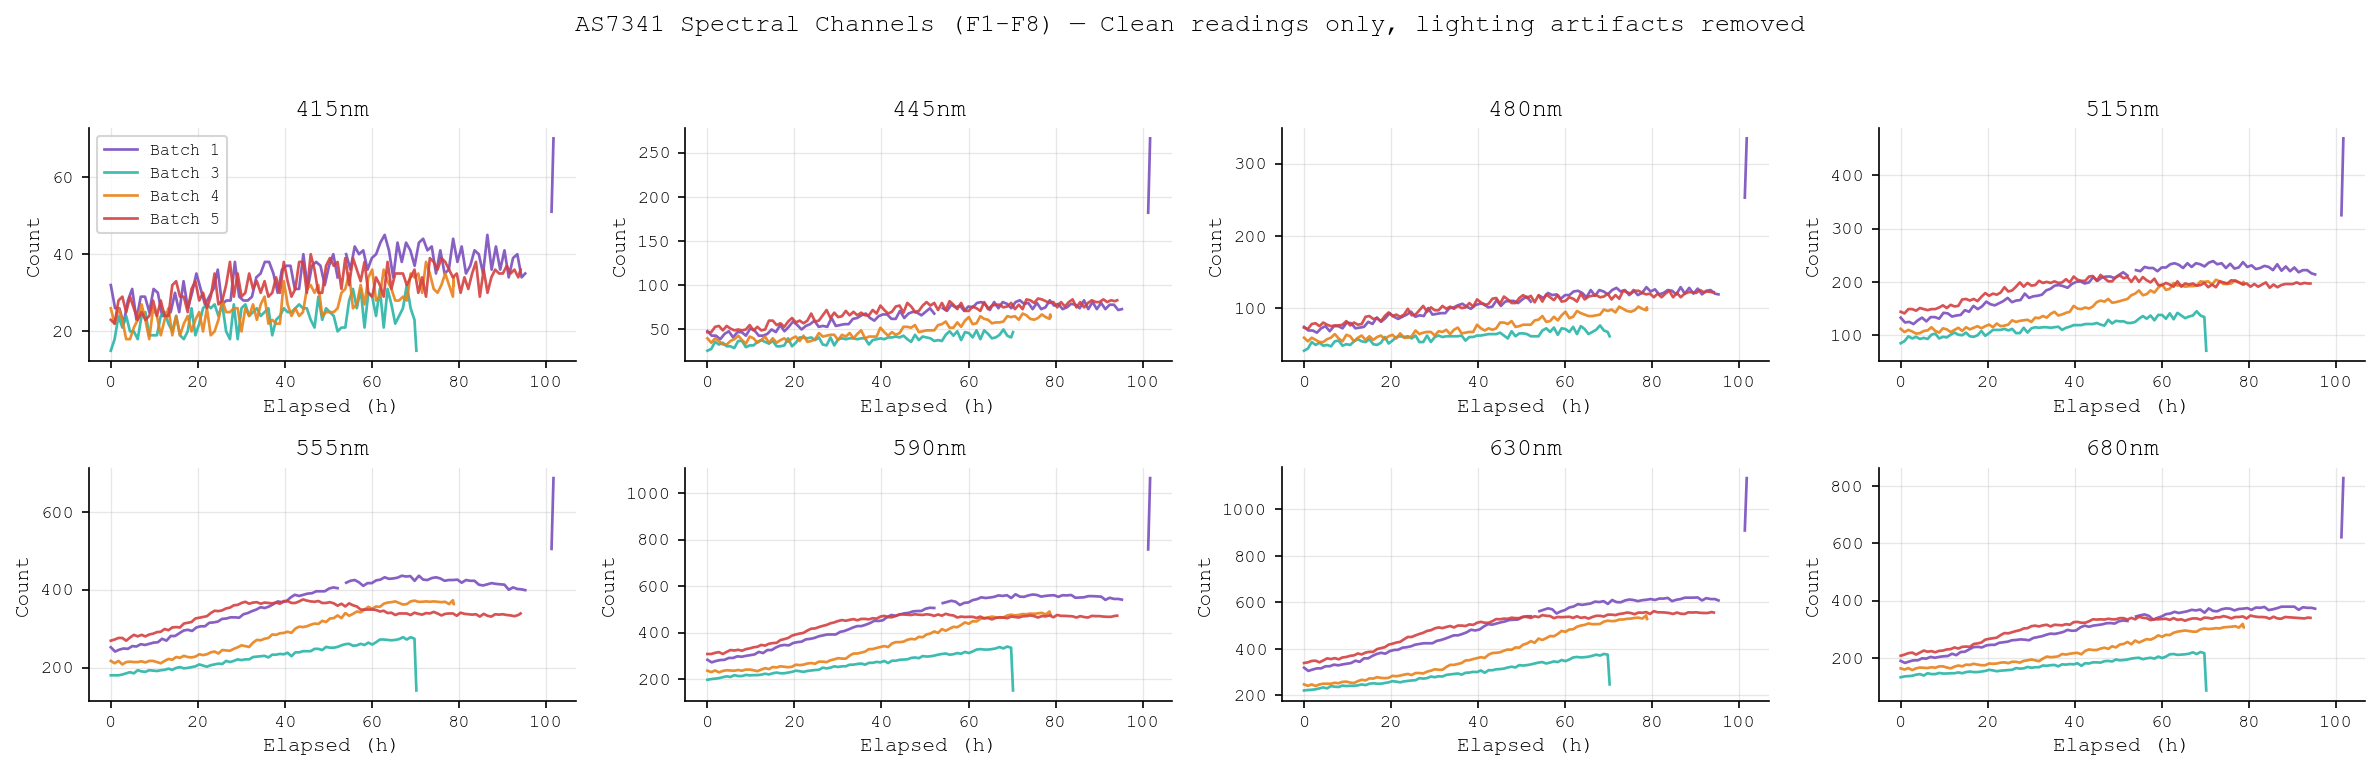

  Saved -> 14_nir_clear.png


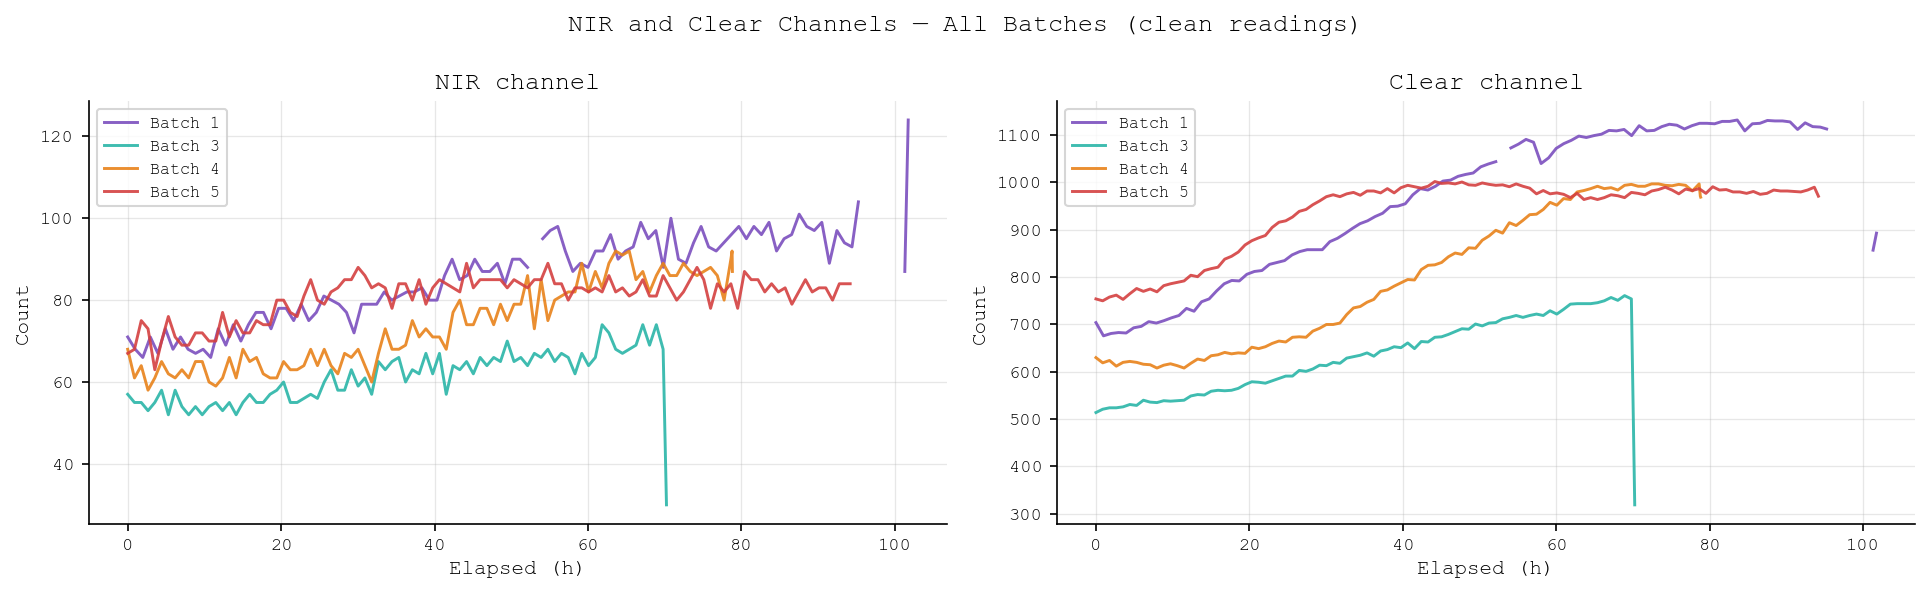

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
axes = axes.flatten()

for ax, col, wl in zip(axes, SPECTRAL_COLS, SPECTRAL_LABELS):
    for i in BATCH_IDS:
        m    = spectral_frames[i]
        meta = BATCH_META[i]
        clean = m[col].where(~m['lit_flag'])
        ax.plot(m['elapsed_h'], clean, color=meta['color'], linewidth=1.3,
                label=meta['label'], alpha=0.9)
    ax.set_title(wl)
    ax.set_xlabel('Elapsed (h)')
    ax.set_ylabel('Count')

axes[0].legend(fontsize=8, framealpha=0.8)
fig.suptitle('AS7341 Spectral Channels (F1-F8) — Clean readings only, lighting artifacts removed',
             fontsize=12, y=1.02)
plt.tight_layout()
save_fig('13_spectral_channels', fig)
plt.show()

# NIR and Clear together
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in [(axes[0], 'nir', 'NIR channel'), (axes[1], 'clear', 'Clear channel')]:
    for i in BATCH_IDS:
        m    = spectral_frames[i]
        meta = BATCH_META[i]
        clean = m[col].where(~m['lit_flag'])
        ax.plot(m['elapsed_h'], clean, color=meta['color'], linewidth=1.4,
                label=meta['label'], alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel('Elapsed (h)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('NIR and Clear Channels — All Batches (clean readings)', fontsize=12)
plt.tight_layout()
save_fig('14_nir_clear', fig)
plt.show()

## 15. Spearman correlation — features vs NIR label  *(new)*

Spearman is rank-based so it captures monotonic relationships without assuming linearity.
Preferable to Pearson for the ordinal NIR label (0/1/2 are ordered but not evenly spaced).
Rule of thumb: |r| > 0.3 is worth something, |r| < 0.1 is noise.
Computed on the training set only (Batches 1 and 3) to avoid using test data.

Spearman correlation — features vs NIR label (train set):
  Feature                          r    p-value  signal
  -------------------------------------------------------
  node1_temp                   0.042     0.4343  noise
  node1_hum                   -0.715     0.0000  STRONG
  node1_tvoc                  -0.005     0.9208  noise
  node1_mq3_ppm                0.569     0.0000  STRONG
  node2_temp                  -0.127     0.0010  weak
  node2_hum                   -0.320     0.0000  STRONG
  node2_tvoc                  -0.592     0.0000  STRONG
  node2_mq3_ppm                0.763     0.0000  STRONG
  delta_node1_tvoc             0.045     0.2469  noise
  delta_node2_tvoc            -0.002     0.9689  noise
  Saved -> 15_spearman_correlation.png


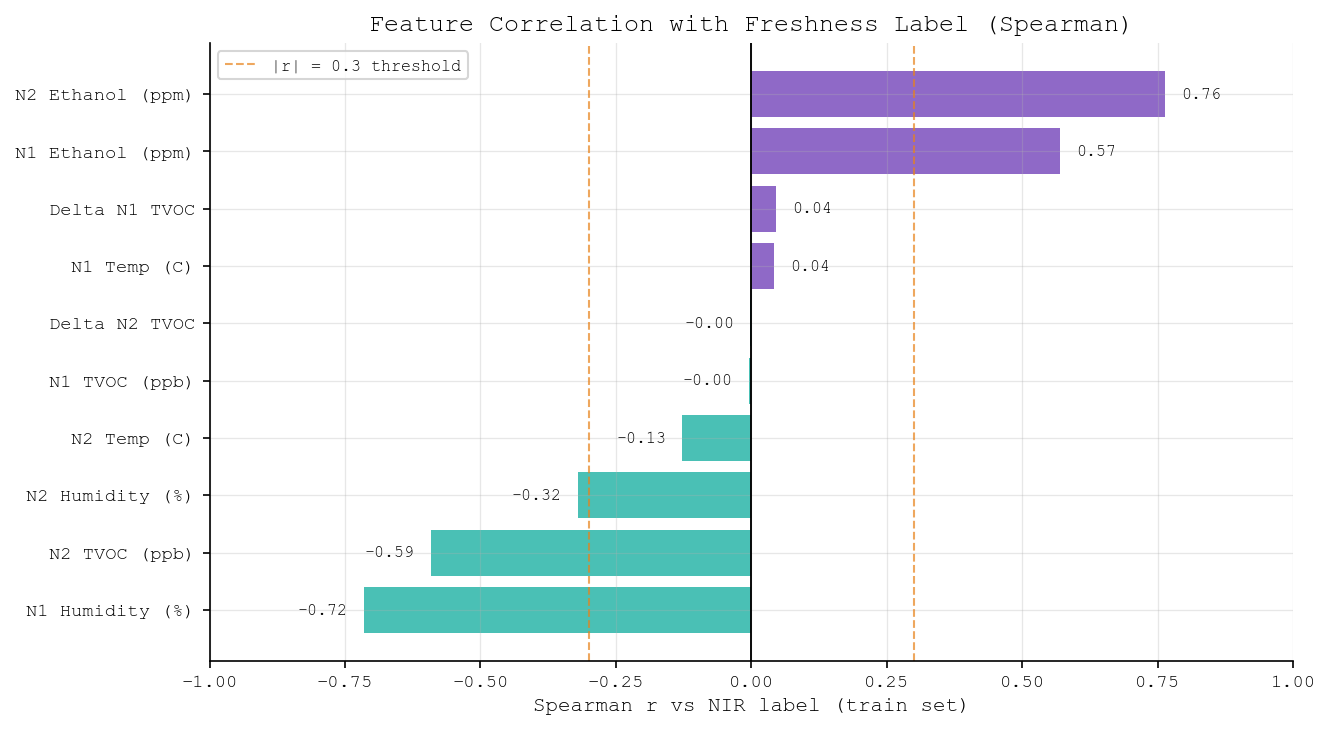


All figures saved to: D:\Masters\Project_leagy_greens\Leafy_Greens_Project\Code\Analysis\figures


In [16]:
print('Spearman correlation — features vs NIR label (train set):')
print(f"  {'Feature':<26} {'r':>7} {'p-value':>10}  signal")
print(f"  {'-'*55}")

r_vals, lbl_list = [], []
for col, lbl in zip(FEATURE_COLS, FEAT_LABELS):
    mask = train_df[col].notna()
    r, p = spearmanr(train_df.loc[mask, col], train_df.loc[mask, 'label'])
    signal = 'STRONG' if abs(r) >= 0.3 else ('weak' if abs(r) >= 0.1 else 'noise')
    print(f"  {col:<26} {r:>7.3f} {p:>10.4f}  {signal}")
    r_vals.append(r)
    lbl_list.append(lbl)

sorted_pairs = sorted(zip(r_vals, lbl_list), key=lambda x: x[0])
r_sorted   = [p[0] for p in sorted_pairs]
lbl_sorted = [p[1] for p in sorted_pairs]
bar_colors = ['#7B4FBE' if v >= 0 else '#2AB5A8' for v in r_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(range(len(r_sorted)), r_sorted, color=bar_colors, alpha=0.85)
ax.set_yticks(range(len(lbl_sorted)))
ax.set_yticklabels(lbl_sorted, fontsize=9)
ax.axvline(0,    color='black',   linewidth=0.9)
ax.axvline(0.3,  color='#E8821A', linewidth=1.0, linestyle='--', alpha=0.7, label='|r| = 0.3 threshold')
ax.axvline(-0.3, color='#E8821A', linewidth=1.0, linestyle='--', alpha=0.7)
ax.set_xlabel('Spearman r vs NIR label (train set)')
ax.set_title('Feature Correlation with Freshness Label (Spearman)')
ax.set_xlim(-1, 1)
ax.legend(fontsize=8)
for bar, val in zip(bars, r_sorted):
    offset = 0.03 if val >= 0 else -0.03
    ha     = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha=ha, fontsize=8)

plt.tight_layout()
save_fig('15_spearman_correlation', fig)
plt.show()

print(f'\nAll figures saved to: {FIGURES_DIR}')